# 🦠 COVID-19 End-to-End Data Science
## Complete Lab Notebook — DSE3231 (Labs 1–10)

**Dataset:** [Our World in Data — COVID-19](https://covid.ourworldindata.org/data/owid-covid-data.csv)

| Lab | Topic | Course Outcome |
|-----|-------|---------------|
| 1 | Data Collection & Import (CSV, Excel, JSON, DB) | DSE3231.1 |
| 2 | Data Cleaning (Missing Values, Duplicates, Types) | DSE3231.1 |
| 3 | Feature Engineering & Scaling | DSE3231.1 |
| 4 | Exploratory Data Analysis (Univariate + Multivariate) | DSE3231.2 |
| 5 | Static Visualization (Bar, Histogram, Box, Heatmap) | DSE3231.2 |
| 6 | Interactive Visualization (Plotly) | DSE3231.2 |
| 7 | Regression Models (Linear, Ridge, Logistic) | DSE3231.3 |
| 8 | Classification Models (DT, RF, SVM, GBM) | DSE3231.3 |
| 9 | Clustering (K-Means, Hierarchical) | DSE3231.4 |
| 10 | Deep Learning (LSTM, BiGRU, CNN-LSTM) | DSE3231.5 |

> **Run in Google Colab:** `Runtime → Run All`


In [1]:
# ============================================================
#  COVID-19 END-TO-END DATA SCIENCE — Google Colab Notebook
#  Covers Labs 1-10 from DSE3231 Lecture Plan
#  Dataset: Our World in Data — COVID-19
# ============================================================
# HOW TO USE:
#   1. Open Google Colab (colab.research.google.com)
#   2. File → Upload notebook  OR  paste cell by cell
#   3. Runtime → Run All   (or run each cell individually)
# ============================================================


## 📥 Lab 1 — Data Collection and Import
**Course Outcome:** DSE3231.1 | **Assessment:** Viva, Lab Record, Project

In [2]:
# ── 1.1: Install & Import Libraries ────────────────── ──

!pip install -q kaggle tensorflow scikit-learn seaborn plotly

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
import io
import requests

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['figure.facecolor'] = 'white'

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [4]:
# ── Cell 1.2: Import Dataset (with fallbacks) ──
import pandas as pd
import numpy as np

df_raw = None

# ── Method 1: Direct GitHub mirror (most reliable) ──
try:
    url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"
    print("⏳ Trying GitHub mirror...")
    df_raw = pd.read_csv(url, parse_dates=['date'], low_memory=False)
    print(f"✅ Loaded from GitHub! Shape: {df_raw.shape}")

except Exception as e:
    print(f"❌ GitHub failed: {e}")

    # ── Method 2: Alternative CDN ──
    try:
        url2 = "https://covid.ourworldindata.org/data/owid-covid-data.csv"
        print("⏳ Trying OWID direct...")
        import urllib.request
        urllib.request.urlretrieve(url2, "owid-covid-data.csv")
        df_raw = pd.read_csv("owid-covid-data.csv", parse_dates=['date'], low_memory=False)
        print(f"✅ Loaded from OWID! Shape: {df_raw.shape}")

    except Exception as e2:
        print(f"❌ OWID failed: {e2}")

        # ── Method 3: Use kaggle dataset ──
        try:
            print("⏳ Trying via requests with headers...")
            import requests, io
            headers = {'User-Agent': 'Mozilla/5.0'}
            r = requests.get(
                "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv",
                headers=headers, timeout=60
            )
            df_raw = pd.read_csv(io.StringIO(r.text), parse_dates=['date'], low_memory=False)
            print(f"✅ Loaded via requests! Shape: {df_raw.shape}")

        except Exception as e3:
            print(f"❌ All URL methods failed.")
            print("👉 Running MANUAL UPLOAD fallback...")

            # ── Method 4: Manual upload ──
            from google.colab import files
            print("\n📂 Please download the file from:")
            print("   https://github.com/owid/covid-19-data/raw/master/public/data/owid-covid-data.csv")
            print("\nThen upload it below 👇")
            uploaded = files.upload()
            filename = list(uploaded.keys())[0]
            df_raw = pd.read_csv(filename, parse_dates=['date'], low_memory=False)
            print(f"✅ Loaded from upload! Shape: {df_raw.shape}")

print(f"\n📋 Dataset Info:")
print(f"   Rows       : {df_raw.shape[0]:,}")
print(f"   Columns    : {df_raw.shape[1]}")
print(f"   Date range : {df_raw['date'].min().date()} → {df_raw['date'].max().date()}")
print(f"   Countries  : {df_raw['location'].nunique()}")
df_raw.head()

⏳ Trying GitHub mirror...
✅ Loaded from GitHub! Shape: (429435, 67)

📋 Dataset Info:
   Rows       : 429,435
   Columns    : 67
   Date range : 2020-01-01 → 2024-08-14
   Countries  : 255


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


In [5]:
# ── 1.3: Import from Excel (demo) ─────────────────── ──

# Save a slice as Excel, then re-read it — demonstrates Excel import
sample_excel_path = "covid_sample.xlsx"
df_raw[df_raw['location'].isin(['India','United States','Brazil'])].head(100).to_excel(
    sample_excel_path, index=False)

df_excel = pd.read_excel(sample_excel_path)
print(f"✅ Excel import: {df_excel.shape}")

# Import from JSON (demo)
json_str = df_raw[df_raw['location'] == 'India'].head(20).to_json(orient='records', date_format='iso')
df_json = pd.read_json(io.StringIO(json_str))
print(f"✅ JSON  import: {df_json.shape}")

# SQLite database demo
import sqlite3
conn = sqlite3.connect(':memory:')
df_raw[df_raw['location'] == 'India'].head(100).to_sql('covid', conn, if_exists='replace', index=False)
df_db = pd.read_sql("SELECT location, date, new_cases, new_deaths FROM covid LIMIT 5", conn)
print(f"✅ SQLite import: {df_db.shape}")
df_db


✅ Excel import: (100, 67)
✅ JSON  import: (20, 67)
✅ SQLite import: (5, 4)


,location,date,new_cases,new_deaths
0,India,2020-01-05 00:00:00,0.0,0.0
1,India,2020-01-06 00:00:00,0.0,0.0
2,India,2020-01-07 00:00:00,0.0,0.0
3,India,2020-01-08 00:00:00,0.0,0.0
4,India,2020-01-09 00:00:00,0.0,0.0


In [6]:
# ── 1.4: Initial Data Exploration ─────────────────── ──

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nShape       : {df_raw.shape}")
print(f"\nColumn names ({len(df_raw.columns)} total):")
print(list(df_raw.columns))
print(f"\nData Types:")
print(df_raw.dtypes.value_counts())
print(f"\nSample data (India, last 5 rows):")
df_raw[df_raw['location']=='India'].tail(5)[
    ['date','new_cases','new_deaths','total_vaccinations','stringency_index']]


DATASET OVERVIEW

Shape       : (429435, 67)

Column names (67 total):
['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients', 'icu_patients_per_million', 'hosp_patients', 'hosp_patients_per_million', 'weekly_icu_admissions', 'weekly_icu_admissions_per_million', 'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'new_vaccinations', 'new_vaccinations_smoothed', 'total_vaccinations_per_hundred', 'people_

,date,new_cases,new_deaths,total_vaccinations,stringency_index
175226,2024-08-08,NaN,NaN,2.206868e+09,NaN
175227,2024-08-09,NaN,NaN,2.206868e+09,NaN
175228,2024-08-10,NaN,NaN,2.206868e+09,NaN
175229,2024-08-11,NaN,NaN,2.206868e+09,NaN
175230,2024-08-12,NaN,NaN,2.206868e+09,NaN


In [7]:
# ── 2.1: Select Key Countries & Columns ───────────── ──

COUNTRIES = [
    'India', 'United States', 'Brazil', 'United Kingdom',
    'Germany', 'France', 'Italy', 'Russia',
    'South Africa', 'Australia', 'Japan', 'Canada',
    'Mexico', 'Argentina', 'Spain'
]

KEY_COLS = [
    'date', 'location', 'continent', 'population',
    'new_cases', 'new_deaths', 'total_cases', 'total_deaths',
    'new_vaccinations', 'total_vaccinations',
    'hosp_patients', 'icu_patients',
    'stringency_index', 'reproduction_rate',
    'gdp_per_capita', 'aged_65_older', 'hospital_beds_per_thousand',
    'diabetes_prevalence', 'female_smokers', 'male_smokers',
    'cardiovasc_death_rate', 'life_expectancy', 'human_development_index'
]

# Keep only columns that exist in the dataset
KEY_COLS = [c for c in KEY_COLS if c in df_raw.columns]
df = df_raw[df_raw['location'].isin(COUNTRIES)][KEY_COLS].copy()
df = df.reset_index(drop=True)

print(f"✅ Filtered dataset: {df.shape}")
print(f"   Countries : {df['location'].nunique()}")
print(f"   Date range: {df['date'].min().date()} → {df['date'].max().date()}")


✅ Filtered dataset: (25129, 23)
   Countries : 15
   Date range: 2020-01-01 → 2024-08-12


MISSING VALUE REPORT
                    Missing Count  Missing %
hosp_patients               14931      59.42
new_vaccinations            13976      55.62
icu_patients                13466      53.59
total_vaccinations          13392      53.29
reproduction_rate            9672      38.49
stringency_index             8741      34.78
new_cases                    1645       6.55
new_deaths                   1205       4.80
total_cases                    19       0.08
total_deaths                   19       0.08


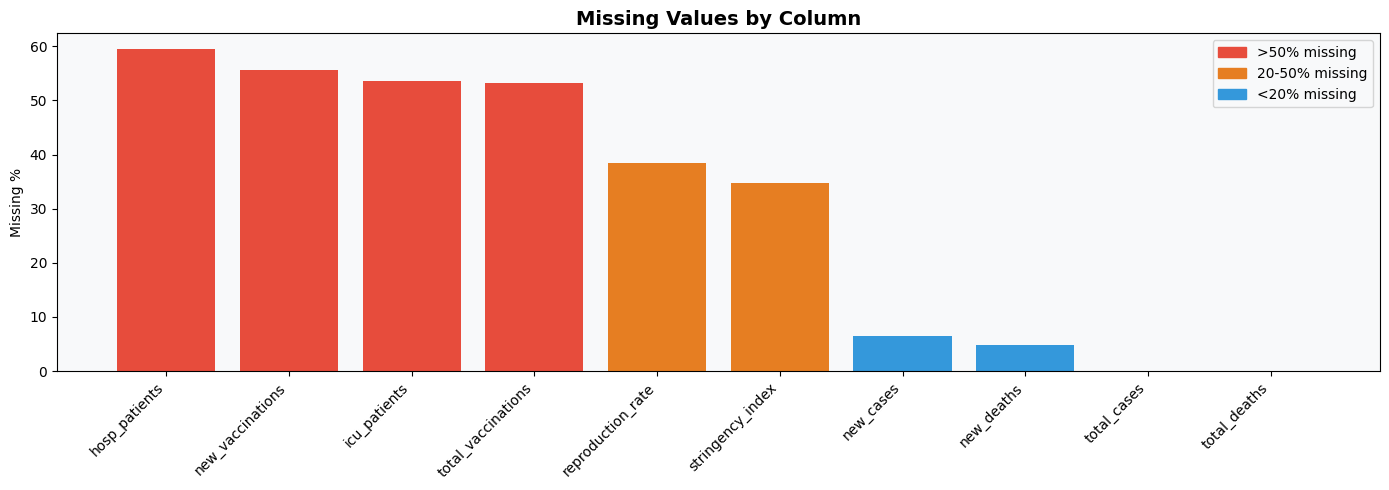

In [8]:
# ── 2.2: Missing Value Analysis ───────────────────── ──

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("MISSING VALUE REPORT")
print("=" * 45)
print(missing_df[missing_df['Missing Count'] > 0].to_string())

# Visualise missing values
plt.figure(figsize=(14, 5))
cols_with_missing = missing_df[missing_df['Missing %'] > 0].index[:20]
pcts = missing_df.loc[cols_with_missing, 'Missing %']
colors = ['#e74c3c' if p > 50 else '#e67e22' if p > 20 else '#3498db' for p in pcts]
plt.bar(range(len(cols_with_missing)), pcts, color=colors)
plt.xticks(range(len(cols_with_missing)), cols_with_missing, rotation=45, ha='right')
plt.ylabel('Missing %')
plt.title('Missing Values by Column', fontsize=14, fontweight='bold')
patches = [mpatches.Patch(color='#e74c3c', label='>50% missing'),
           mpatches.Patch(color='#e67e22', label='20-50% missing'),
           mpatches.Patch(color='#3498db', label='<20% missing')]
plt.legend(handles=patches)
plt.tight_layout()
plt.show()


In [9]:
# ── 2.3: Handle Missing Values ────────────────────── ──

from sklearn.impute import SimpleImputer

# Strategy 1: Fill time-series columns with forward-fill per country
ts_cols = ['new_cases', 'new_deaths', 'total_cases', 'total_deaths',
           'new_vaccinations', 'total_vaccinations', 'hosp_patients',
           'icu_patients', 'stringency_index', 'reproduction_rate']
ts_cols = [c for c in ts_cols if c in df.columns]

df[ts_cols] = df.groupby('location')[ts_cols].transform(
    lambda x: x.fillna(method='ffill').fillna(method='bfill').fillna(0))

# Strategy 2: Static country features — fill with median per country
static_cols = ['gdp_per_capita', 'aged_65_older', 'hospital_beds_per_thousand',
               'diabetes_prevalence', 'life_expectancy', 'human_development_index',
               'cardiovasc_death_rate']
static_cols = [c for c in static_cols if c in df.columns]

df[static_cols] = df.groupby('location')[static_cols].transform(
    lambda x: x.fillna(x.median()))
df[static_cols] = df[static_cols].fillna(df[static_cols].median())

# Clip negative values (data artefacts)
for col in ts_cols:
    df[col] = df[col].clip(lower=0)

print(f"Missing values BEFORE cleaning: {df_raw[KEY_COLS].isnull().sum().sum():,}")
print(f"Missing values AFTER  cleaning: {df.isnull().sum().sum()}")
print(f"✅ All missing values handled!")


Missing values BEFORE cleaning: 3,106,813
Missing values AFTER  cleaning: 0
✅ All missing values handled!


In [10]:
# ── 2.4: Duplicate Detection & Removal ────────────── ──

n_before = len(df)
duplicates = df.duplicated(subset=['date', 'location'])
print(f"Duplicate rows found: {duplicates.sum()}")
df = df.drop_duplicates(subset=['date', 'location']).reset_index(drop=True)
print(f"Rows before: {n_before:,}  |  After: {len(df):,}")


Duplicate rows found: 0
Rows before: 25,129  |  After: 25,129


In [11]:
# ── 2.5: Data Type Conversions ────────────────────── ──

# Ensure correct dtypes
df['date'] = pd.to_datetime(df['date'])
df['location'] = df['location'].astype('category')
df['continent'] = df['continent'].astype('category')

int_cols = ['new_cases', 'new_deaths', 'total_cases', 'total_deaths', 'new_vaccinations']
int_cols = [c for c in int_cols if c in df.columns]
df[int_cols] = df[int_cols].astype(int)

print("Data types after conversion:")
print(df.dtypes.to_string())
print(f"\n✅ Dataset ready: {df.shape}")


Data types after conversion:
date                          datetime64[ns]
location                            category
continent                           category
population                             int64
new_cases                              int64
new_deaths                             int64
total_cases                            int64
total_deaths                           int64
new_vaccinations                       int64
total_vaccinations                   float64
hosp_patients                        float64
icu_patients                         float64
stringency_index                     float64
reproduction_rate                    float64
gdp_per_capita                       float64
aged_65_older                        float64
hospital_beds_per_thousand           float64
diabetes_prevalence                  float64
female_smokers                       float64
male_smokers                         float64
cardiovasc_death_rate                float64
life_expectancy           

In [12]:
# ── 3.1: Create Derived Features ──────────────────── ──

# Rate features
df['case_fatality_rate']   = np.where(df['total_cases'] > 0,
                                       df['total_deaths'] / df['total_cases'], 0)
df['cases_per_million']    = df['new_cases']  / df['population'] * 1e6
df['deaths_per_million']   = df['new_deaths'] / df['population'] * 1e6
df['vacc_per_hundred']     = df['total_vaccinations'] / df['population'] * 100

# Hospitalisation rate (cases → hospitalised)
if 'hosp_patients' in df.columns:
    df['hosp_rate'] = np.where(df['new_cases'] > 0,
                                df['hosp_patients'] / df['new_cases'], 0)

# Rolling 7-day average (smoothed trend)
df = df.sort_values(['location', 'date'])
df['cases_7day_avg'] = df.groupby('location')['new_cases'].transform(
    lambda x: x.rolling(7, min_periods=1).mean())

# Temporal features
df['year']         = df['date'].dt.year
df['month']        = df['date'].dt.month
df['quarter']      = df['date'].dt.quarter
df['day_of_week']  = df['date'].dt.dayofweek
df['days_since_start'] = (df['date'] - df['date'].min()).dt.days

# Binary wave indicator (rough wave periods)
df['pandemic_wave'] = pd.cut(df['month'],
                              bins=[0,3,6,9,12],
                              labels=['Q1','Q2','Q3','Q4'])

print("✅ New features created:")
new_feats = ['case_fatality_rate','cases_per_million','deaths_per_million',
             'vacc_per_hundred','cases_7day_avg','year','month','quarter',
             'day_of_week','days_since_start']
for f in new_feats:
    if f in df.columns:
        print(f"   ✔ {f}")


✅ New features created:
   ✔ case_fatality_rate
   ✔ cases_per_million
   ✔ deaths_per_million
   ✔ vacc_per_hundred
   ✔ cases_7day_avg
   ✔ year
   ✔ month
   ✔ quarter
   ✔ day_of_week
   ✔ days_since_start


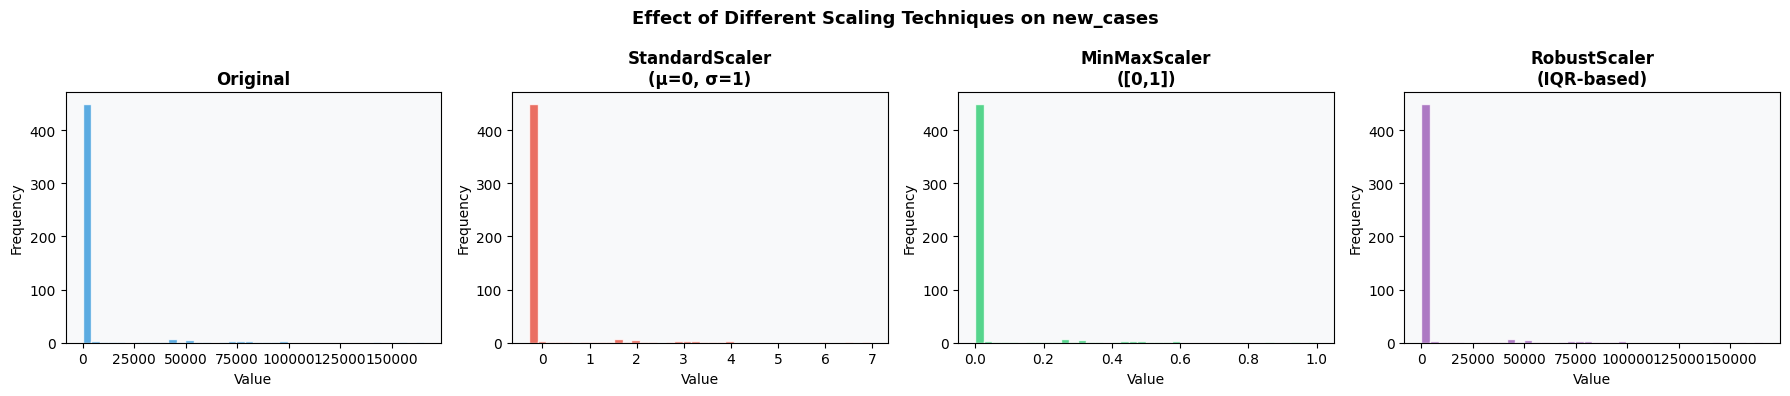

✅ Scaling techniques demonstrated!


In [13]:
# ── 3.2: Feature Scaling ───────────────────────────── ──

from sklearn.preprocessing import (StandardScaler, MinMaxScaler,
                                    RobustScaler, LabelEncoder, OneHotEncoder)

NUMERIC_FEATURES = [
    'new_cases', 'new_deaths', 'stringency_index', 'cases_per_million',
    'deaths_per_million', 'gdp_per_capita', 'aged_65_older',
    'hospital_beds_per_thousand', 'diabetes_prevalence', 'life_expectancy',
    'cases_7day_avg', 'case_fatality_rate', 'days_since_start'
]
NUMERIC_FEATURES = [f for f in NUMERIC_FEATURES if f in df.columns]

df_scale_demo = df[NUMERIC_FEATURES].dropna().head(500)

std_scaler   = StandardScaler()
mm_scaler    = MinMaxScaler()
rob_scaler   = RobustScaler()

X_std = std_scaler.fit_transform(df_scale_demo)
X_mm  = mm_scaler.fit_transform(df_scale_demo)
X_rob = rob_scaler.fit_transform(df_scale_demo)

# Visualise effect on 'new_cases'
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
data_versions = [df_scale_demo['new_cases'].values, X_std[:,0], X_mm[:,0], X_rob[:,0]]
titles = ['Original', 'StandardScaler\n(μ=0, σ=1)', 'MinMaxScaler\n([0,1])', 'RobustScaler\n(IQR-based)']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

for ax, data, title, color in zip(axes, data_versions, titles, colors):
    ax.hist(data, bins=40, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Value'); ax.set_ylabel('Frequency')

plt.suptitle('Effect of Different Scaling Techniques on new_cases', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Scaling techniques demonstrated!")


PCA Explained Variance:
  PC1:  24.2%  ████████████
  PC2:  21.5%  ██████████
  PC3:  12.8%  ██████
  PC4:   8.4%  ████
  PC5:   7.5%  ███

  Total explained: 74.3%


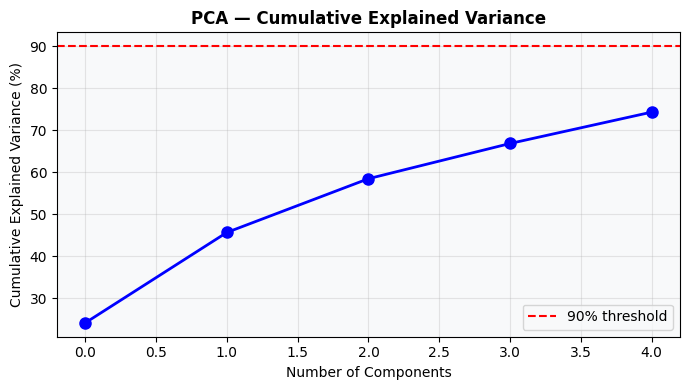

✅ Encoding and PCA done!


In [14]:
# ── 3.3: Encoding & PCA ────────────────────────────── ──

from sklearn.decomposition import PCA

# Label Encoding
le = LabelEncoder()
df['continent_enc'] = le.fit_transform(df['continent'].astype(str))
df['location_enc']  = LabelEncoder().fit_transform(df['location'].astype(str))

# PCA on numeric features
pca_data = df[NUMERIC_FEATURES].fillna(0)
X_scaled = std_scaler.fit_transform(pca_data)
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(5)])

print("PCA Explained Variance:")
for i, ev in enumerate(pca.explained_variance_ratio_):
    bar = '█' * int(ev * 50)
    print(f"  PC{i+1}: {ev*100:5.1f}%  {bar}")
print(f"\n  Total explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Cumulative variance plot
plt.figure(figsize=(7, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_)*100, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=90, color='r', linestyle='--', label='90% threshold')
plt.xlabel('Number of Components'); plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA — Cumulative Explained Variance', fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print("✅ Encoding and PCA done!")


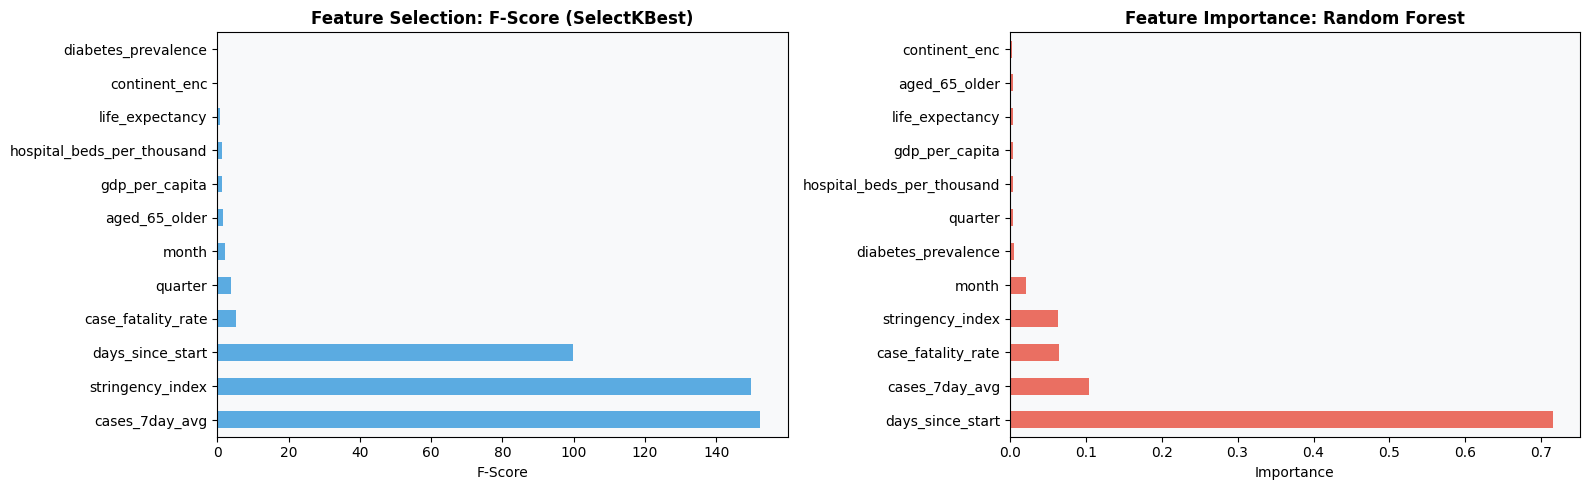

✅ Top 8 features selected: ['days_since_start', 'cases_7day_avg', 'case_fatality_rate', 'stringency_index', 'month', 'diabetes_prevalence', 'quarter', 'hospital_beds_per_thousand']


In [15]:
# ── 3.4: Feature Selection ─────────────────────────── ──

from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

# Prepare X, y for feature selection
ML_FEATURES = [
    'gdp_per_capita','aged_65_older','hospital_beds_per_thousand',
    'diabetes_prevalence','stringency_index','life_expectancy',
    'days_since_start','month','quarter','continent_enc',
    'cases_7day_avg', 'case_fatality_rate'
]
ML_FEATURES = [f for f in ML_FEATURES if f in df.columns]
TARGET = 'new_cases'

df_ml = df[ML_FEATURES + [TARGET]].dropna()
X_fs = df_ml[ML_FEATURES].values
y_fs = np.log1p(df_ml[TARGET].values)

# Method 1: SelectKBest (F-score)
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_fs, y_fs)
f_scores = pd.Series(selector.scores_, index=ML_FEATURES).sort_values(ascending=False)

# Method 2: Random Forest importances
rf_fs = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_fs.fit(X_fs, y_fs)
rf_imp = pd.Series(rf_fs.feature_importances_, index=ML_FEATURES).sort_values(ascending=False)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
f_scores.plot(kind='barh', ax=axes[0], color='#3498db', alpha=0.8)
axes[0].set_title('Feature Selection: F-Score (SelectKBest)', fontweight='bold')
axes[0].set_xlabel('F-Score')

rf_imp.plot(kind='barh', ax=axes[1], color='#e74c3c', alpha=0.8)
axes[1].set_title('Feature Importance: Random Forest', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout(); plt.show()

# Top features
TOP_FEATURES = rf_imp.head(8).index.tolist()
print(f"✅ Top 8 features selected: {TOP_FEATURES}")


In [16]:
# ── 4.1: Statistical Summaries ────────────────────── ──

print("=" * 60)
print("STATISTICAL SUMMARY — KEY COVID METRICS")
print("=" * 60)

summary_cols = ['new_cases','new_deaths','cases_per_million',
                'deaths_per_million','stringency_index',
                'case_fatality_rate','reproduction_rate']
summary_cols = [c for c in summary_cols if c in df.columns]

stats = df[summary_cols].describe().T
stats['cv%'] = (stats['std'] / stats['mean'] * 100).round(1)  # Coefficient of variation
stats['skew'] = df[summary_cols].skew().round(3)
stats['kurtosis'] = df[summary_cols].kurt().round(3)
print(stats.round(3).to_string())


STATISTICAL SUMMARY — KEY COVID METRICS
                      count       mean         std  min     25%     50%     75%          max     cv%    skew  kurtosis
new_cases           25129.0  16941.753  119293.096  0.0   0.000   0.000   0.000  5650933.000   704.1  18.416   561.124
new_deaths          25129.0    177.077    1118.562  0.0   0.000   0.000   0.000    28982.000   631.7  11.937   190.031
cases_per_million   25129.0    160.544    1065.209  0.0   0.000   0.000   0.000    35642.768   663.5  13.501   254.206
deaths_per_million  25129.0      1.357       6.953  0.0   0.000   0.000   0.000      144.025   512.5   8.312    90.498
stringency_index    25129.0     36.030      25.115  0.0  11.110  29.850  56.940      100.000    69.7   0.472    -1.032
case_fatality_rate  25129.0      1.382      32.882  0.0   0.009   0.016   0.027     1038.750  2378.9  26.660   738.946
reproduction_rate   25129.0      1.041       0.445  0.0   0.830   0.990   1.180        4.080    42.8   1.960     8.270


In [17]:
# ── 4.2: Country-Level Aggregation ────────────────── ──

agg = df.groupby('location').agg(
    total_cases       = ('new_cases', 'sum'),
    total_deaths      = ('new_deaths', 'sum'),
    total_vacc        = ('new_vaccinations', 'sum'),
    peak_cases        = ('new_cases', 'max'),
    avg_stringency    = ('stringency_index', 'mean'),
    avg_cfr           = ('case_fatality_rate', 'mean'),
    gdp               = ('gdp_per_capita', 'first'),
    aged              = ('aged_65_older', 'first'),
    beds              = ('hospital_beds_per_thousand', 'first'),
    diabetes          = ('diabetes_prevalence', 'first'),
    life_exp          = ('life_expectancy', 'first'),
    population        = ('population', 'first'),
    continent         = ('continent', 'first')
).reset_index()

agg['cases_per_million']  = agg['total_cases']  / agg['population'] * 1e6
agg['deaths_per_million'] = agg['total_deaths'] / agg['population'] * 1e6
agg['cfr_pct']            = agg['total_deaths'] / agg['total_cases'] * 100

print("\nCountry-level aggregated summary:")
print(agg[['location','total_cases','total_deaths','cfr_pct','avg_stringency']].to_string(index=False))



Country-level aggregated summary:
      location  total_cases  total_deaths  cfr_pct  avg_stringency
     Argentina     10101218        130663 1.293537       39.232116
     Australia     11861161         25312 0.213402       34.763417
        Brazil     37511921        702116 1.871714       39.506995
        Canada      4819055         55613 1.154023       34.872772
        France     38997490        167985 0.430758       31.539265
       Germany     38437756        174979 0.455227       32.697838
         India     45044252        533623 1.184664       47.772444
         Italy     26800128        197325 0.736284       41.841049
         Japan     33803572         74694 0.220965       38.011129
        Mexico      7619458        334551 4.390745       33.550858
        Russia     24268728        403188 1.661348       30.848065
  South Africa      4072765        102595 2.519050       32.575520
         Spain     13980340        121852 0.871595       31.368548
United Kingdom     24974629

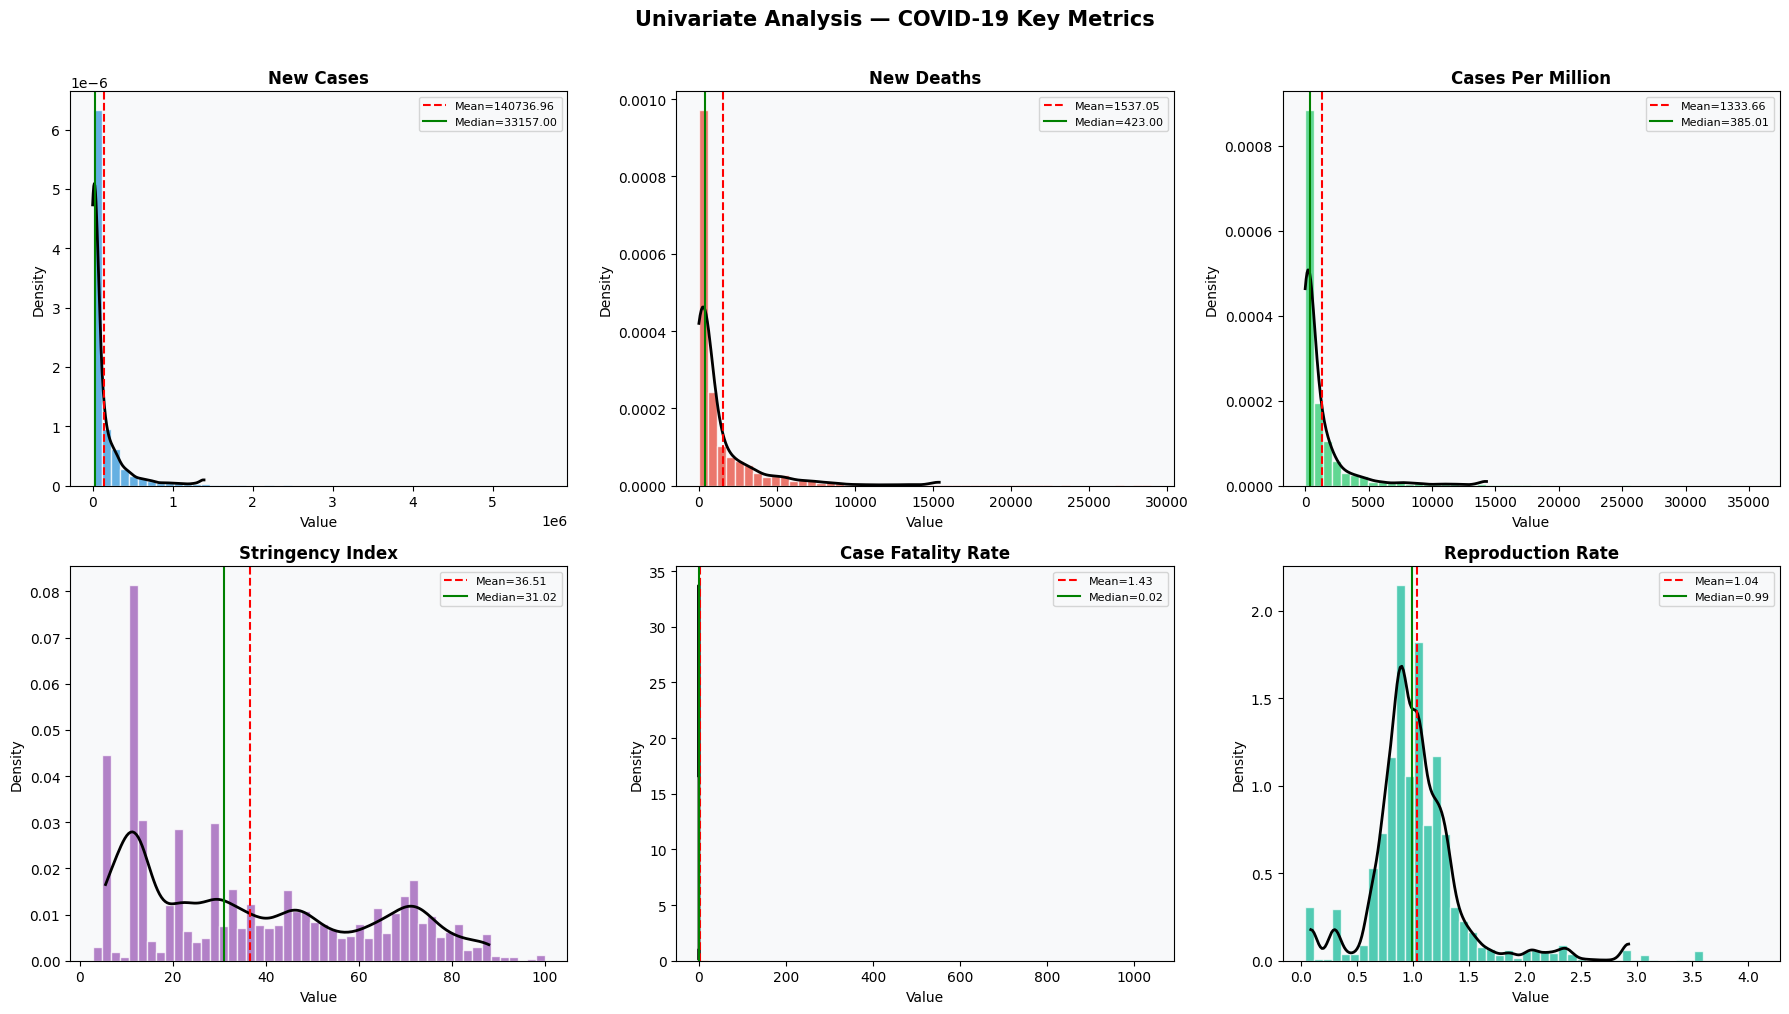

In [18]:
# ── 4.3: Univariate Analysis ───────────────────────── ──

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

univariate_cols = ['new_cases','new_deaths','cases_per_million',
                   'stringency_index','case_fatality_rate','reproduction_rate']
univariate_cols = [c for c in univariate_cols if c in df.columns]
palette = ['#3498db','#e74c3c','#2ecc71','#9b59b6','#e67e22','#1abc9c']

for i, (col, color) in enumerate(zip(univariate_cols, palette)):
    ax = axes[i]
    data = df[col].replace(0, np.nan).dropna()
    ax.hist(data, bins=50, color=color, alpha=0.75, edgecolor='white', density=True)

    # Overlay KDE
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data.clip(data.quantile(0.01), data.quantile(0.99)))
    x_range = np.linspace(data.quantile(0.01), data.quantile(0.99), 200)
    ax.plot(x_range, kde(x_range), 'k-', linewidth=2)

    ax.axvline(data.mean(),   color='red',   linestyle='--', linewidth=1.5, label=f'Mean={data.mean():.2f}')
    ax.axvline(data.median(), color='green', linestyle='-',  linewidth=1.5, label=f'Median={data.median():.2f}')
    ax.set_title(col.replace('_',' ').title(), fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlabel('Value'); ax.set_ylabel('Density')

plt.suptitle('Univariate Analysis — COVID-19 Key Metrics', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


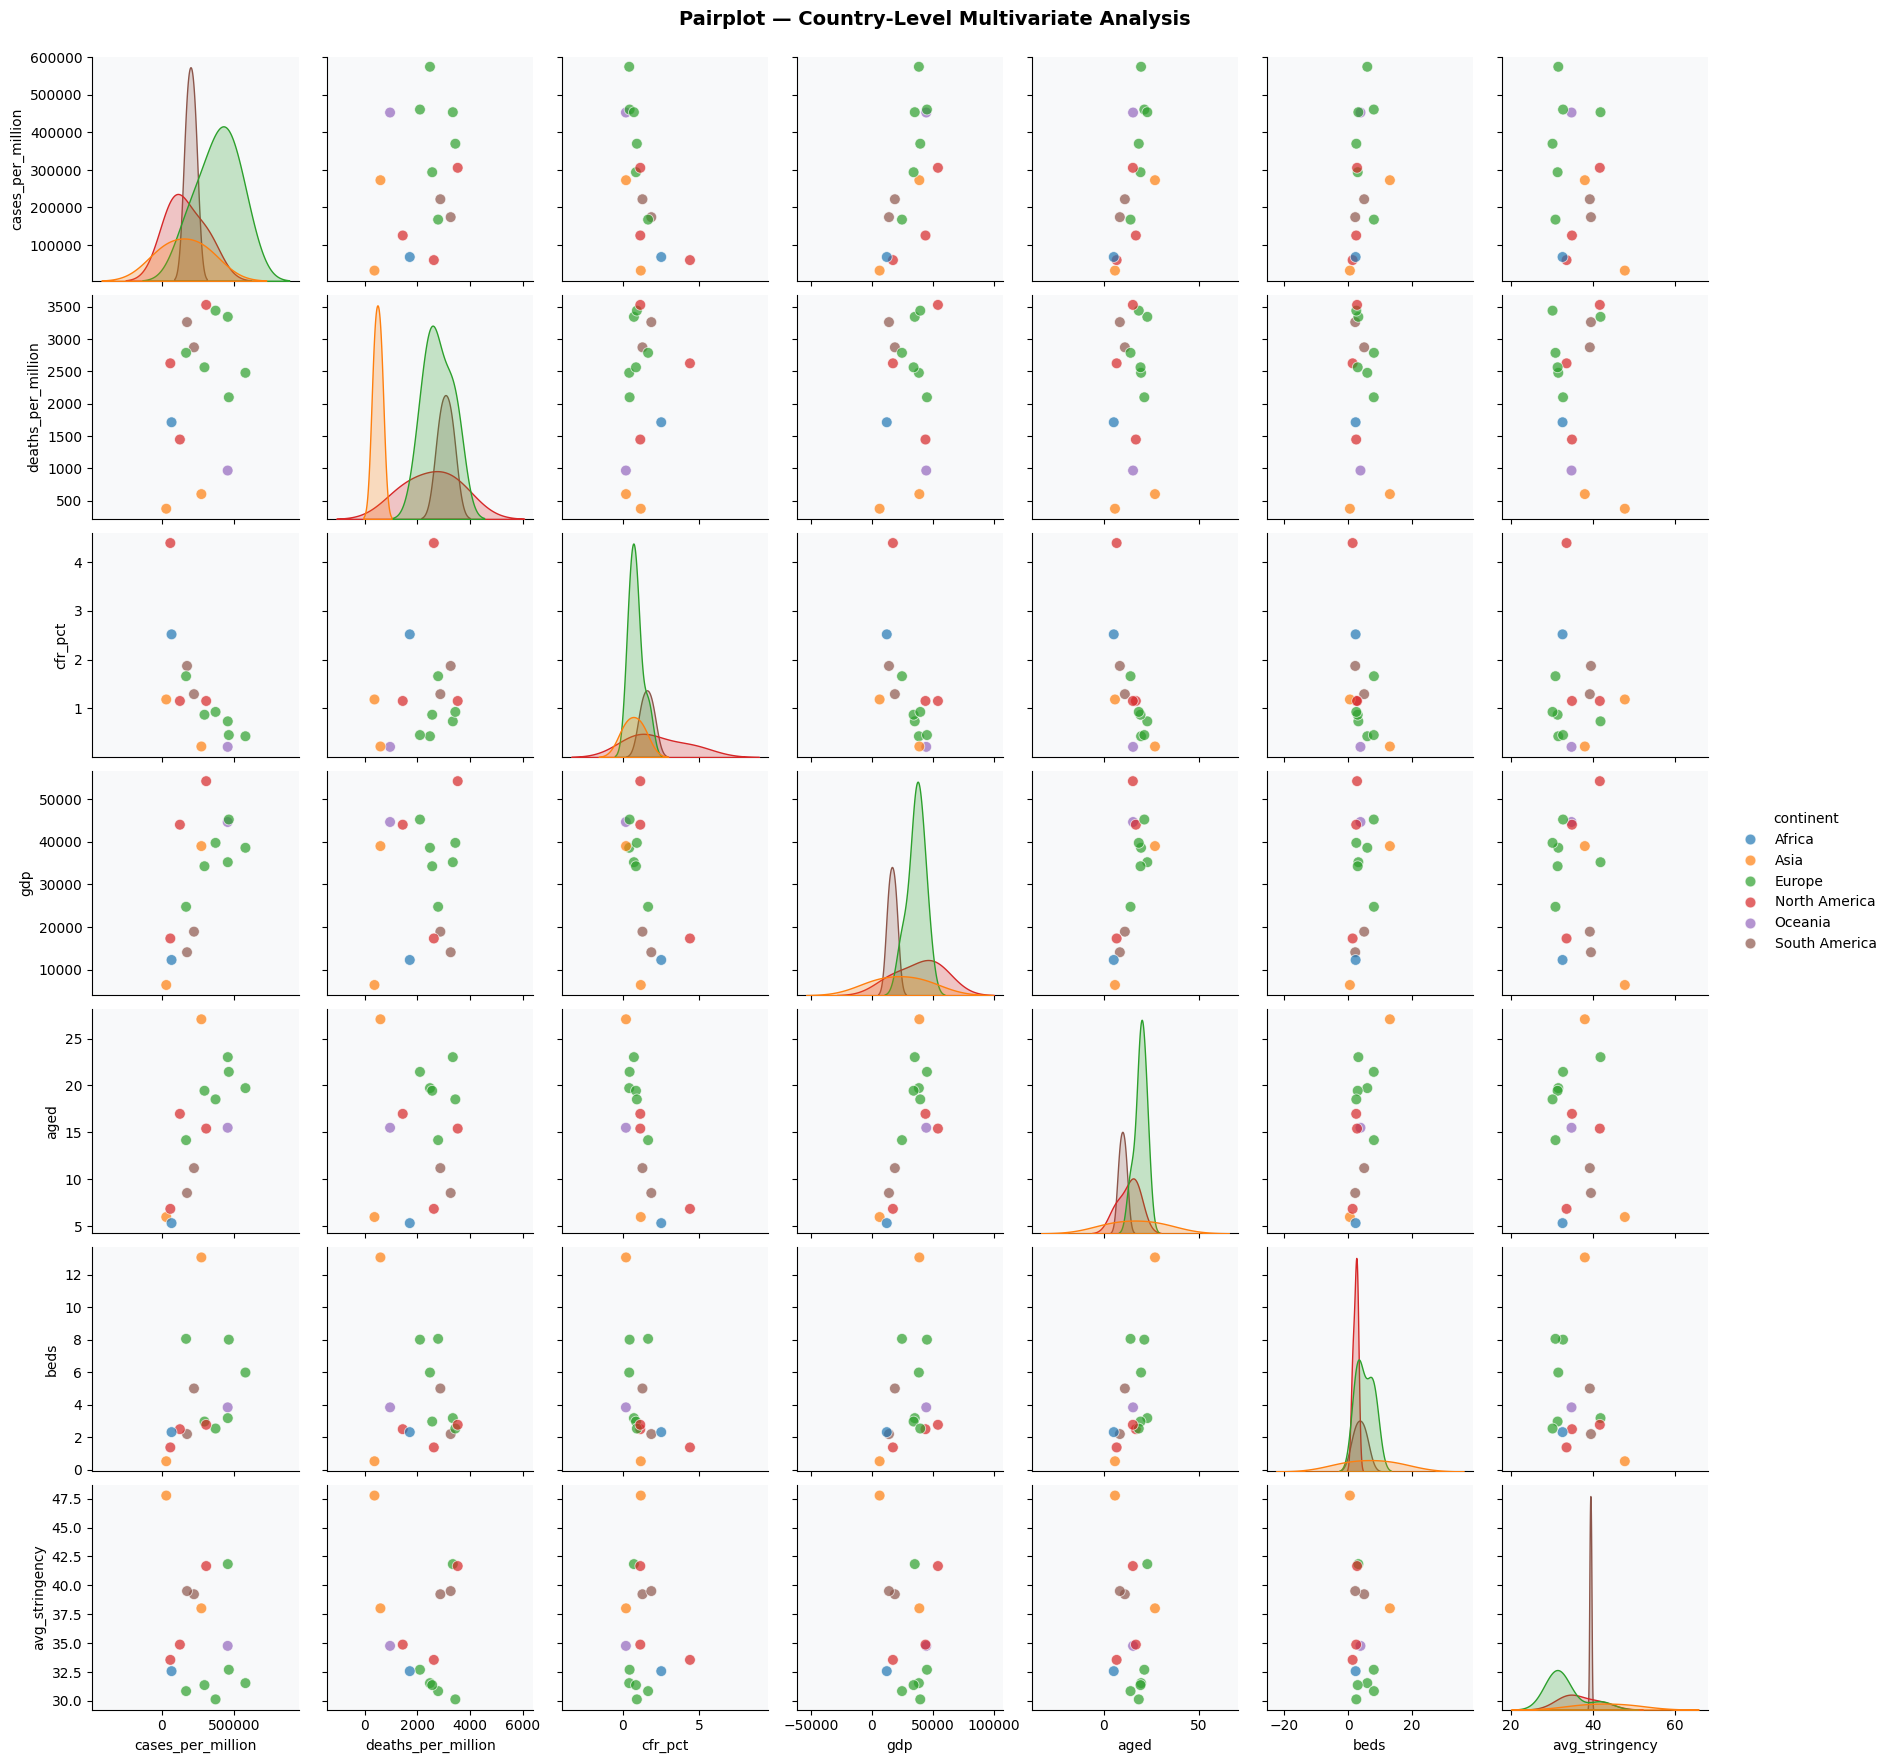


Mean metrics by continent:
               new_cases  new_deaths  stringency_index
continent                                             
Africa            2433.0        61.3              32.6
Asia             23494.6       181.3              42.9
Europe           16667.6       129.1              33.1
North America    23055.2       315.0              36.7
Oceania           7085.5        15.1              34.8
South America    14204.4       248.4              39.4


In [19]:
# ── 4.4: Multivariate Analysis ────────────────────── ──

# Pairplot on country aggregates
pair_cols = ['cases_per_million','deaths_per_million','cfr_pct',
             'gdp','aged','beds','avg_stringency']
pair_cols = [c for c in pair_cols if c in agg.columns]

g = sns.pairplot(agg[pair_cols + ['continent']].dropna(),
                 hue='continent', diag_kind='kde',
                 plot_kws={'alpha':0.7, 's':60},
                 diag_kws={'fill':True})
g.figure.suptitle('Pairplot — Country-Level Multivariate Analysis', y=1.01, fontsize=14, fontweight='bold')
plt.show()

# Grouped means by continent
print("\nMean metrics by continent:")
print(df.groupby('continent')[['new_cases','new_deaths','stringency_index']].mean().round(1).to_string())


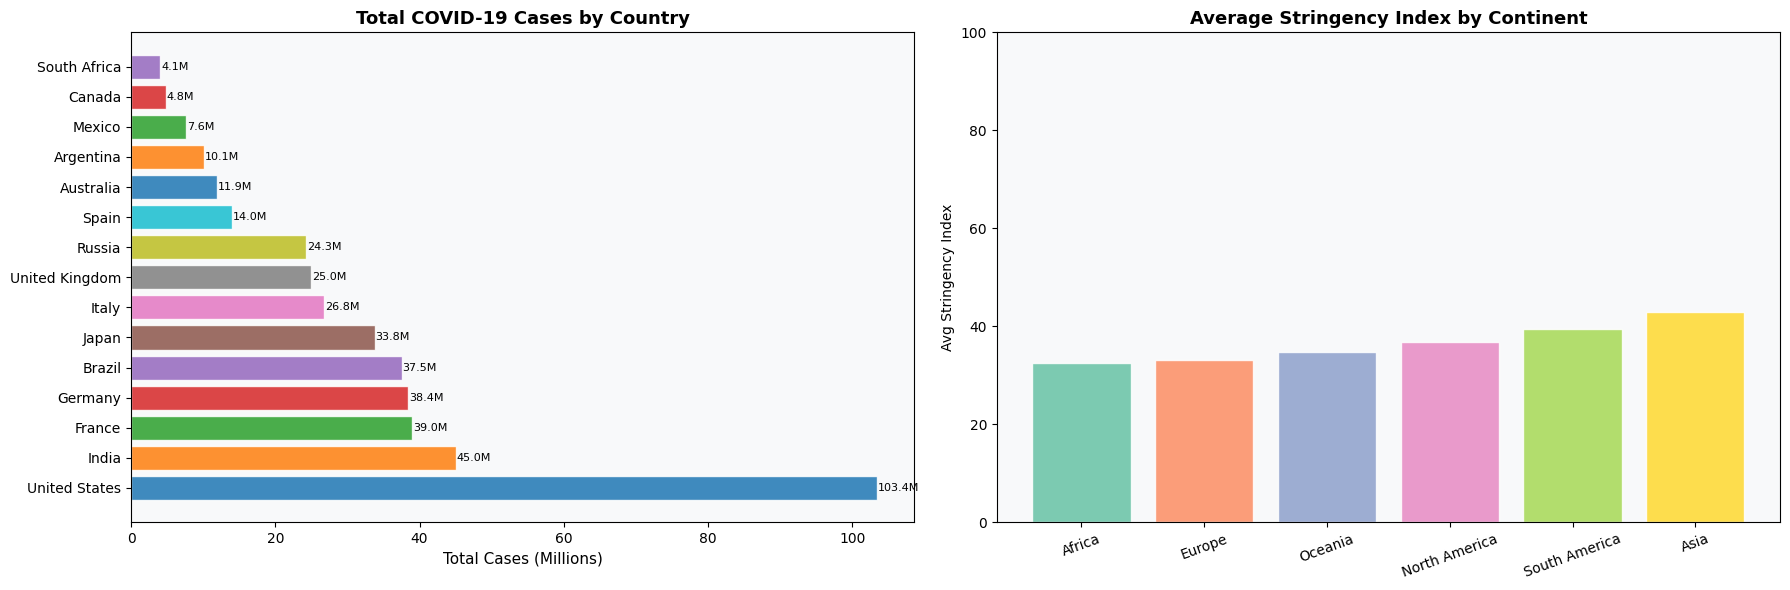

In [20]:
# ── 5.1: Bar Charts ────────────────────────────────── ──

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Total cases per country
top_countries = agg.sort_values('total_cases', ascending=False)
colors = sns.color_palette('tab10', len(top_countries))
axes[0].barh(top_countries['location'], top_countries['total_cases']/1e6,
             color=colors, alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Total Cases (Millions)', fontsize=11)
axes[0].set_title('Total COVID-19 Cases by Country', fontweight='bold', fontsize=13)
for i, (val, loc) in enumerate(zip(top_countries['total_cases'], top_countries['location'])):
    axes[0].text(val/1e6 + 0.1, i, f'{val/1e6:.1f}M', va='center', fontsize=8)

# Average stringency by continent
cont_str = df.groupby(['continent','location'])['stringency_index'].mean().reset_index()
cont_str_mean = cont_str.groupby('continent')['stringency_index'].mean().sort_values()
axes[1].bar(cont_str_mean.index, cont_str_mean.values,
            color=sns.color_palette('Set2', len(cont_str_mean)), alpha=0.85, edgecolor='white')
axes[1].set_title('Average Stringency Index by Continent', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Avg Stringency Index'); axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout(); plt.show()


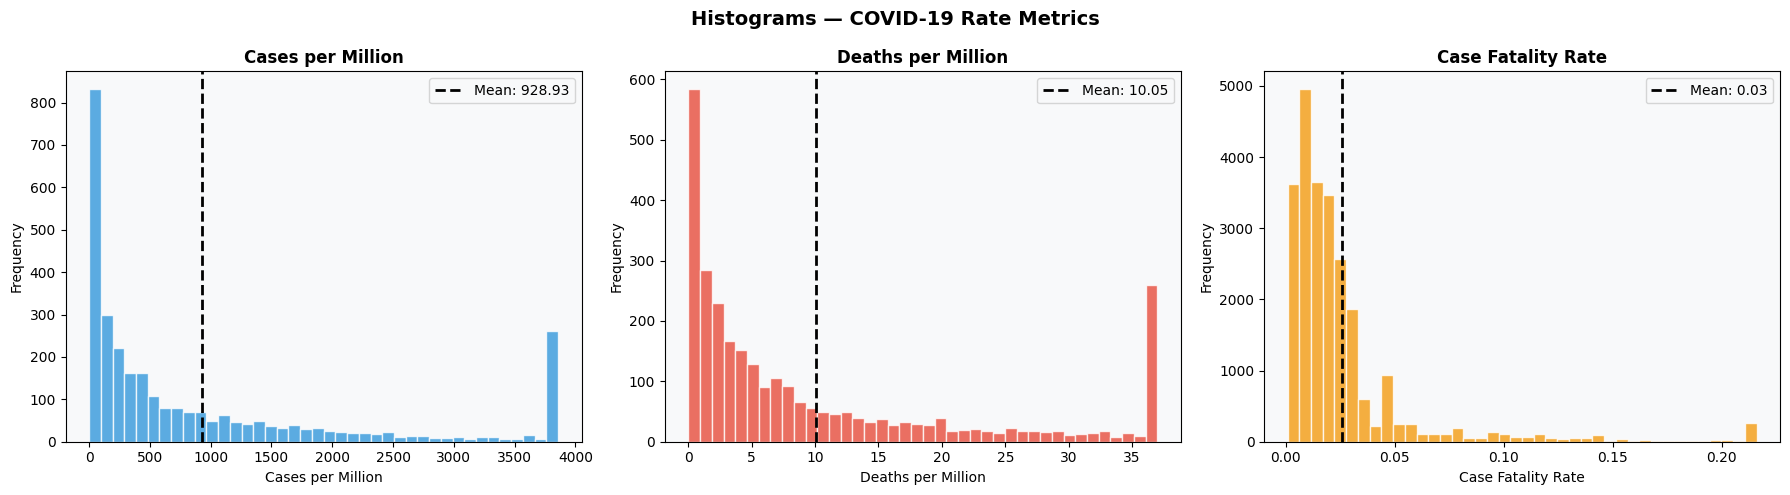

In [21]:
# ── 5.2: Histograms ────────────────────────────────── ──

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['cases_per_million', 'deaths_per_million', 'case_fatality_rate']
titles  = ['Cases per Million', 'Deaths per Million', 'Case Fatality Rate']
colors  = ['#3498db', '#e74c3c', '#f39c12']

for ax, col, title, color in zip(axes, metrics, titles, colors):
    data = df[col].replace(0, np.nan).dropna().clip(upper=df[col].quantile(0.99))
    ax.hist(data, bins=40, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(data.mean(), color='black', linewidth=2, linestyle='--', label=f'Mean: {data.mean():.2f}')
    ax.set_title(title, fontweight='bold'); ax.legend()
    ax.set_xlabel(title); ax.set_ylabel('Frequency')

plt.suptitle('Histograms — COVID-19 Rate Metrics', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


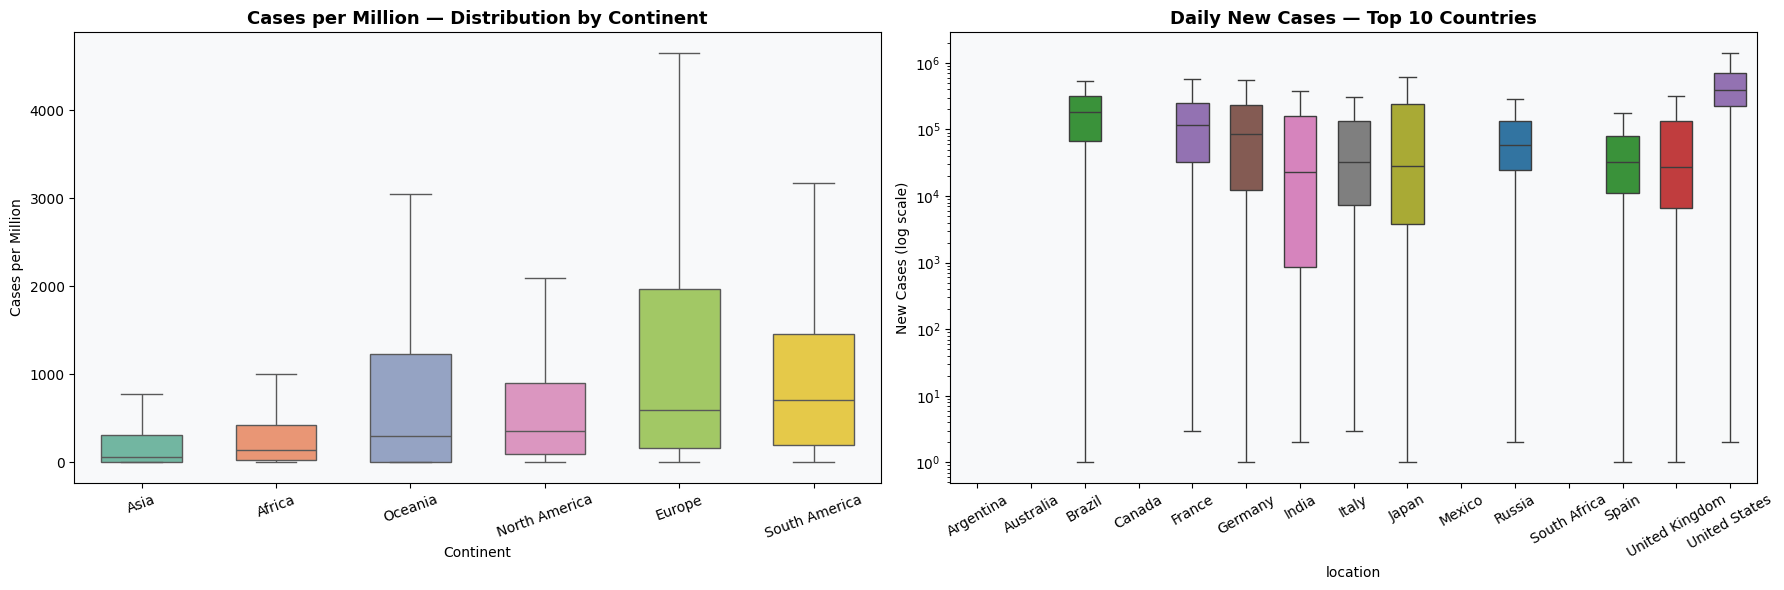

In [22]:
# ── 5.3: Box Plots ─────────────────────────────────── ──

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Box plot: cases per million by continent
df_bp = df[df['cases_per_million'] > 0].copy()
continent_order = df_bp.groupby('continent')['cases_per_million'].median().sort_values().index.tolist()
sns.boxplot(data=df_bp, x='continent', y='cases_per_million',
            order=continent_order, palette='Set2', ax=axes[0],
            showfliers=False, width=0.6)
axes[0].set_title('Cases per Million — Distribution by Continent', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Cases per Million'); axes[0].set_xlabel('Continent')
axes[0].tick_params(axis='x', rotation=20)

# Box plot: new_cases by country (log scale)
top10 = agg.nlargest(10, 'total_cases')['location'].tolist()
df_top10 = df[df['location'].isin(top10) & (df['new_cases'] > 0)]
sns.boxplot(data=df_top10, x='location', y='new_cases',
            palette='tab10', ax=axes[1], showfliers=False, width=0.6)
axes[1].set_title('Daily New Cases — Top 10 Countries', fontweight='bold', fontsize=13)
axes[1].set_yscale('log'); axes[1].set_ylabel('New Cases (log scale)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()


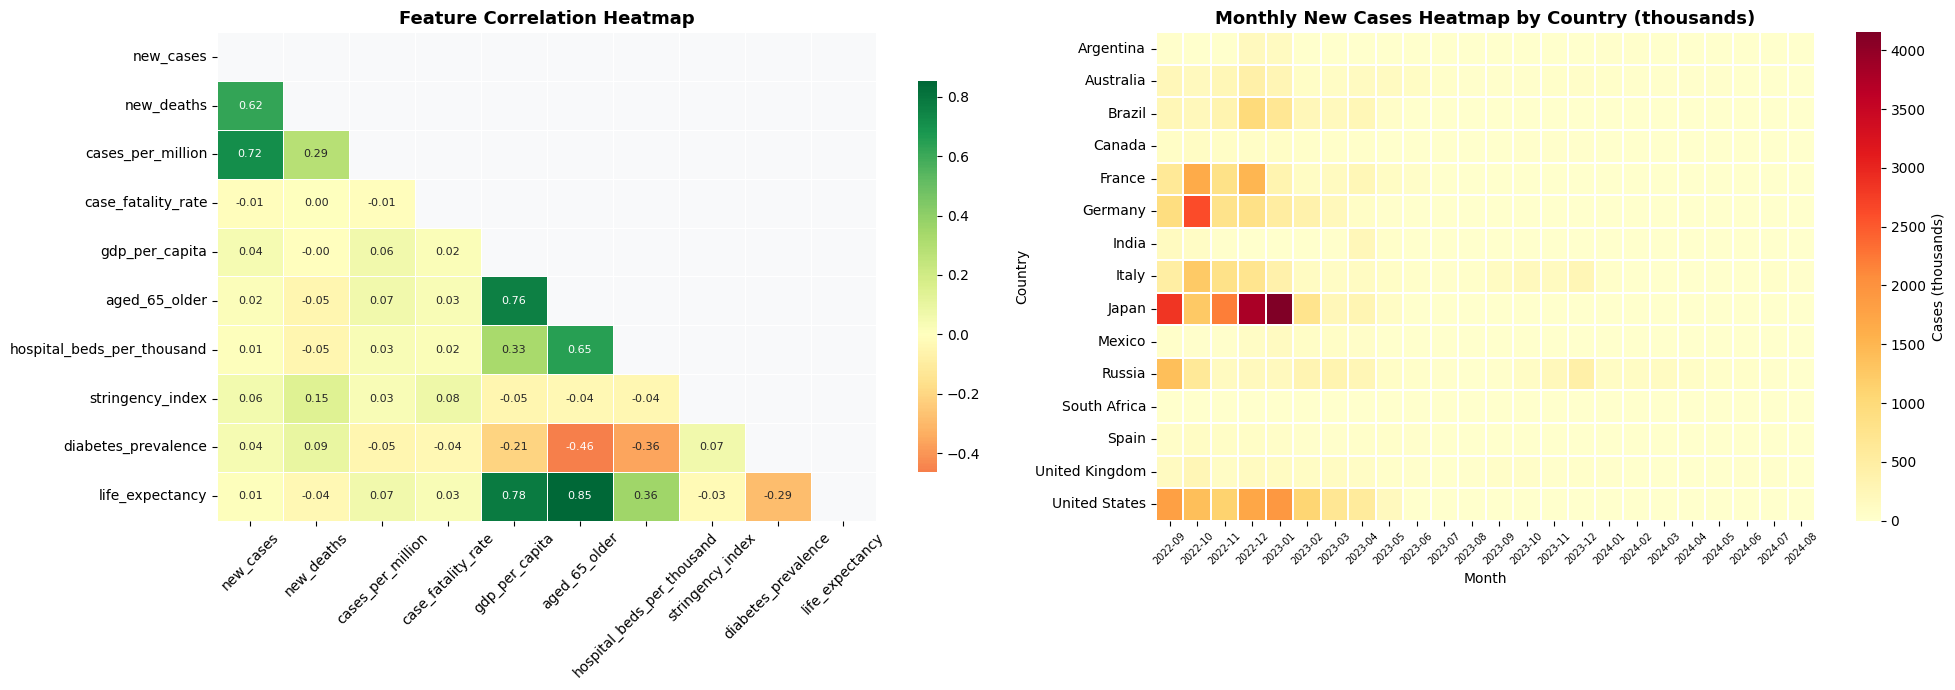

In [23]:
# ── 5.4: Heatmaps ──────────────────────────────────── ──

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Heatmap 1: Correlation matrix
corr_cols = ['new_cases','new_deaths','cases_per_million','case_fatality_rate',
             'gdp_per_capita','aged_65_older','hospital_beds_per_thousand',
             'stringency_index','diabetes_prevalence','life_expectancy']
corr_cols = [c for c in corr_cols if c in df.columns]
corr_matrix = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[0], linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 8})
axes[0].set_title('Feature Correlation Heatmap', fontweight='bold', fontsize=13)
axes[0].tick_params(axis='x', rotation=45)

# Heatmap 2: Monthly cases by country (pivot heatmap)
df_heat = df.copy()
df_heat['year_month'] = df_heat['date'].dt.to_period('M').astype(str)
pivot = df_heat.pivot_table(values='new_cases', index='location',
                             columns='year_month', aggfunc='sum')
# Show last 24 months only
pivot = pivot.iloc[:, -24:]
sns.heatmap(pivot/1e3, ax=axes[1], cmap='YlOrRd',
            fmt='.0f', linewidths=0.2, cbar_kws={'label': 'Cases (thousands)'})
axes[1].set_title('Monthly New Cases Heatmap by Country (thousands)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Month'); axes[1].set_ylabel('Country')
axes[1].tick_params(axis='x', rotation=45, labelsize=7)

plt.tight_layout(); plt.show()


In [24]:
# ── 6.1: Interactive Charts with Plotly ───────────── ──

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Chart 1: Animated time-series by country
df_plot = df[df['new_cases'] > 0].copy()
df_plot['year_month'] = df_plot['date'].dt.to_period('M').astype(str)
monthly = df_plot.groupby(['location','year_month','continent'])[
    ['new_cases','new_deaths','cases_per_million']].sum().reset_index()
monthly_top = monthly[monthly['location'].isin(
    agg.nlargest(10,'total_cases')['location'].tolist())]

fig1 = px.line(monthly_top, x='year_month', y='new_cases',
               color='location', markers=True,
               title='Monthly New COVID-19 Cases — Top 10 Countries',
               labels={'new_cases':'New Cases','year_month':'Month'},
               template='plotly_white')
fig1.update_layout(hovermode='x unified', legend_title='Country',
                   xaxis_tickangle=-45)
fig1.show()


# Chart 2: Interactive bubble chart
fig2 = px.scatter(agg, x='gdp', y='cfr_pct',
                  size='cases_per_million', color='continent',
                  hover_name='location', size_max=60,
                  title='GDP per Capita vs Case Fatality Rate<br>(bubble size = cases per million)',
                  labels={'gdp':'GDP per Capita (USD)', 'cfr_pct':'Case Fatality Rate (%)'},
                  template='plotly_white')
fig2.show()


# Chart 3: Interactive heatmap (stringency over time)
df_str = df.copy()
df_str['month_year'] = df_str['date'].dt.to_period('M').astype(str)
pivot_str = df_str.pivot_table(values='stringency_index', index='location',
                                columns='month_year', aggfunc='mean')
pivot_str = pivot_str.iloc[:, -24:]

fig3 = px.imshow(pivot_str,
                 color_continuous_scale='RdYlGn_r',
                 title='Stringency Index Heatmap by Country (last 24 months)',
                 labels=dict(color='Stringency'),
                 aspect='auto')
fig3.update_xaxes(tickangle=-45)
fig3.show()


# Chart 4: Multi-panel dashboard
fig4 = make_subplots(rows=2, cols=2,
    subplot_titles=('Daily Cases (7-day avg) — Top 5 Countries',
                    'Total Deaths by Country',
                    'Vaccination Progress',
                    'Cases vs Deaths Scatter'))

top5 = agg.nlargest(5,'total_cases')['location'].tolist()
colors_px = px.colors.qualitative.Set1

for i, country in enumerate(top5):
    d = df[df['location']==country].sort_values('date')
    fig4.add_trace(go.Scatter(x=d['date'], y=d['cases_7day_avg'],
                              name=country, line=dict(color=colors_px[i]),
                              showlegend=True), row=1, col=1)

fig4.add_trace(go.Bar(x=agg['location'], y=agg['total_deaths'],
                       marker_color='#e74c3c', showlegend=False,
                       name='Deaths'), row=1, col=2)

if 'vacc_per_hundred' in df.columns:
    vacc_latest = df.groupby('location')['vacc_per_hundred'].max().reset_index()
    fig4.add_trace(go.Bar(x=vacc_latest['location'],
                          y=vacc_latest['vacc_per_hundred'],
                          marker_color='#2ecc71', showlegend=False,
                          name='Vacc/100'), row=2, col=1)

fig4.add_trace(go.Scatter(x=agg['cases_per_million'],
                           y=agg['deaths_per_million'],
                           mode='markers+text',
                           text=agg['location'], textposition='top center',
                           marker=dict(size=10, color='#9b59b6'),
                           showlegend=False), row=2, col=2)

fig4.update_layout(height=700, title_text='COVID-19 Interactive Dashboard',
                   template='plotly_white')
fig4.show()


In [25]:
# ── 7.1: Prepare Regression Dataset ───────────────── ──

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

REG_FEATURES = [
    'gdp_per_capita', 'aged_65_older', 'hospital_beds_per_thousand',
    'diabetes_prevalence', 'stringency_index', 'life_expectancy',
    'days_since_start', 'month', 'quarter', 'continent_enc',
    'cases_7day_avg'
]
REG_FEATURES = [f for f in REG_FEATURES if f in df.columns]
REG_TARGET   = 'new_cases'

df_reg = df[REG_FEATURES + [REG_TARGET]].dropna()
df_reg = df_reg[df_reg[REG_TARGET] >= 0]

X = df_reg[REG_FEATURES].values
y = np.log1p(df_reg[REG_TARGET].values)   # log transform for stability

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Training set  : {X_train.shape}")
print(f"Test set      : {X_test.shape}")
print(f"Target (log)  : min={y.min():.2f}, max={y.max():.2f}, mean={y.mean():.2f}")


Training set  : (20103, 11)
Test set      : (5026, 11)
Target (log)  : min=0.00, max=15.55, mean=1.20


In [26]:
# ── 7.2: Linear Regression ────────────────────────── ──

lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)

print("── LINEAR REGRESSION ─────────────────────")
print(f"  R²  : {r2_score(y_test, y_pred_lr):.4f}")
print(f"  MAE : {mean_absolute_error(y_test, y_pred_lr):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.4f}")
print(f"  CV R² (5-fold): {cross_val_score(lr, X_train_s, y_train, cv=5, scoring='r2').mean():.4f}")


── LINEAR REGRESSION ─────────────────────
  R²  : 0.0105
  MAE : 2.0747
  RMSE: 3.2967
  CV R² (5-fold): 0.0092


In [27]:
# ── 7.3: Ridge Regression ──────────────────────────── ──

from sklearn.linear_model import RidgeCV
ridge = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100])
ridge.fit(X_train_s, y_train)
y_pred_ridge = ridge.predict(X_test_s)

print("── RIDGE REGRESSION ──────────────────────")
print(f"  Best α: {ridge.alpha_}")
print(f"  R²  : {r2_score(y_test, y_pred_ridge):.4f}")
print(f"  MAE : {mean_absolute_error(y_test, y_pred_ridge):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.4f}")


── RIDGE REGRESSION ──────────────────────
  Best α: 100.0
  R²  : 0.0105
  MAE : 2.0747
  RMSE: 3.2968


In [31]:
# ── Cell 7.4: Logistic Regression (FIXED) ──
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Features ──
CLS_FEATURES = [
    'gdp_per_capita', 'aged_65_older', 'hospital_beds_per_thousand',
    'diabetes_prevalence', 'stringency_index', 'life_expectancy',
    'days_since_start', 'month', 'continent_enc'
]
CLS_FEATURES = [f for f in CLS_FEATURES if f in df.columns]
for extra in ['cases_7day_avg', 'case_fatality_rate']:
    if extra in df.columns and extra not in CLS_FEATURES:
        CLS_FEATURES.append(extra)

# ── Create binary target using MEDIAN (not quantile) ──
df_cls = df.copy()

# Filter out zero-case rows first
df_cls = df_cls[df_cls['new_cases'] > 0].reset_index(drop=True)

# Use median split — guarantees 50/50 class balance
median_cases = df_cls['new_cases'].median()
df_cls['high_severity'] = (df_cls['new_cases'] >= median_cases).astype(int)

print(f"Median threshold : {median_cases:,.0f}")
print(f"Class 0 (Normal) : {(df_cls['high_severity']==0).sum():,}")
print(f"Class 1 (High)   : {(df_cls['high_severity']==1).sum():,}")

# ── Drop NaN ──
df_cls2 = df_cls[CLS_FEATURES + ['high_severity']].dropna().reset_index(drop=True)
print(f"Clean dataset    : {df_cls2.shape}")

X_c = df_cls2[CLS_FEATURES].values.astype(float)
y_c = df_cls2['high_severity'].values

# Replace any remaining inf/nan
X_c = np.nan_to_num(X_c, nan=0.0, posinf=0.0, neginf=0.0)

print(f"Unique classes   : {np.unique(y_c)}")

# ── Split & Scale ──
X_c_tr, X_c_te, y_c_tr, y_c_te = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42, stratify=y_c)

sc2 = StandardScaler()
X_c_tr_s = sc2.fit_transform(X_c_tr)
X_c_te_s  = sc2.transform(X_c_te)

# ── Train ──
log_clf = LogisticRegression(max_iter=1000, random_state=42, C=1.0, solver='lbfgs')
log_clf.fit(X_c_tr_s, y_c_tr)

y_c_pred = log_clf.predict(X_c_te_s)
y_c_prob = log_clf.predict_proba(X_c_te_s)[:, 1]

print("\n── LOGISTIC REGRESSION ───────────────────")
print(f"  Accuracy : {(y_c_pred == y_c_te).mean():.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_c_te, y_c_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_c_te, y_c_pred, target_names=['Normal', 'High']))

Median threshold : 33,157
Class 0 (Normal) : 1,512
Class 1 (High)   : 1,513
Clean dataset    : (3025, 12)
Unique classes   : [0 1]

── LOGISTIC REGRESSION ───────────────────
  Accuracy : 0.9405
  ROC-AUC  : 0.9956

Classification Report:
              precision    recall  f1-score   support

      Normal       0.90      0.99      0.94       302
        High       0.99      0.89      0.94       303

    accuracy                           0.94       605
   macro avg       0.95      0.94      0.94       605
weighted avg       0.95      0.94      0.94       605



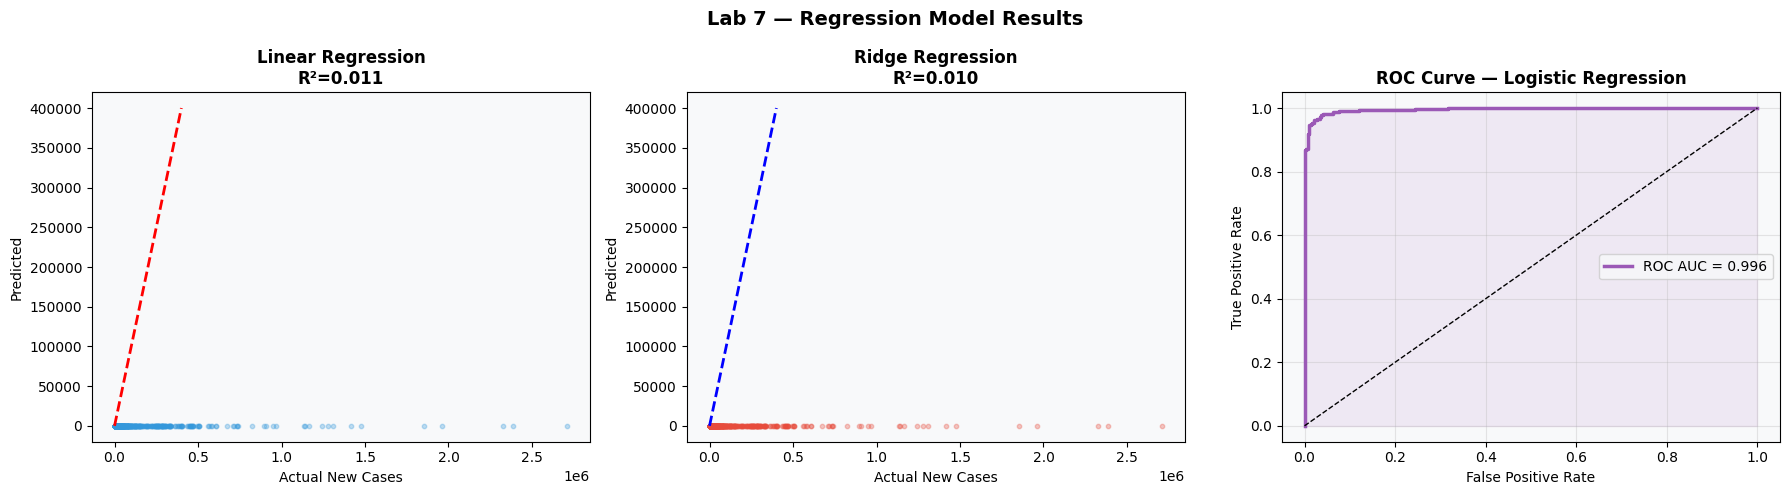

In [32]:
# ── 7.5: Regression Plots ──────────────────────────── ──

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted — Linear
axes[0].scatter(np.expm1(y_test), np.expm1(y_pred_lr), alpha=0.3, color='#3498db', s=10)
mn, mx = 0, np.expm1(y_test).quantile(0.99) if hasattr(np.expm1(y_test),'quantile') else np.expm1(y_test).max()
lim = [0, np.percentile(np.expm1(y_test), 99)]
axes[0].plot(lim, lim, 'r--', linewidth=2)
axes[0].set_title(f'Linear Regression\nR²={r2_score(y_test,y_pred_lr):.3f}', fontweight='bold')
axes[0].set_xlabel('Actual New Cases'); axes[0].set_ylabel('Predicted')

# Actual vs Predicted — Ridge
axes[1].scatter(np.expm1(y_test), np.expm1(y_pred_ridge), alpha=0.3, color='#e74c3c', s=10)
axes[1].plot(lim, lim, 'b--', linewidth=2)
axes[1].set_title(f'Ridge Regression\nR²={r2_score(y_test,y_pred_ridge):.3f}', fontweight='bold')
axes[1].set_xlabel('Actual New Cases'); axes[1].set_ylabel('Predicted')

# ROC Curve — Logistic
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_c_te, y_c_prob)
axes[2].plot(fpr, tpr, color='#9b59b6', linewidth=2.5,
             label=f'ROC AUC = {roc_auc_score(y_c_te, y_c_prob):.3f}')
axes[2].plot([0,1],[0,1],'k--', linewidth=1)
axes[2].fill_between(fpr, tpr, alpha=0.1, color='#9b59b6')
axes[2].set_title('ROC Curve — Logistic Regression', fontweight='bold')
axes[2].set_xlabel('False Positive Rate'); axes[2].set_ylabel('True Positive Rate')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('Lab 7 — Regression Model Results', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


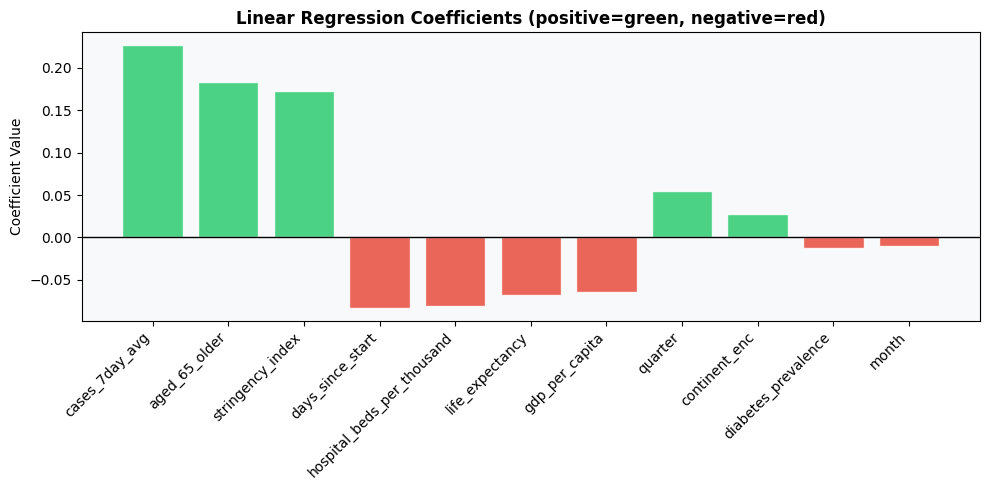

In [33]:
# ── 7.6: Coefficient Analysis ─────────────────────── ──

coef_df = pd.DataFrame({'Feature': REG_FEATURES, 'Coefficient': lr.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_df['Coefficient']]
plt.bar(range(len(coef_df)), coef_df['Coefficient'], color=colors, edgecolor='white', alpha=0.85)
plt.xticks(range(len(coef_df)), coef_df['Feature'], rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=1)
plt.title('Linear Regression Coefficients (positive=green, negative=red)', fontweight='bold')
plt.ylabel('Coefficient Value')
plt.tight_layout(); plt.show()


In [35]:
# ── Cell 8.1: Prepare Multi-class Target (FIXED) ──
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

CLS3_FEATURES = [
    'gdp_per_capita', 'aged_65_older', 'hospital_beds_per_thousand',
    'diabetes_prevalence', 'stringency_index', 'days_since_start',
    'month', 'continent_enc', 'cases_7day_avg', 'case_fatality_rate'
]
CLS3_FEATURES = [f for f in CLS3_FEATURES if f in df.columns]

# ── Filter out zero-case rows first ──
df_cls3 = df[df['new_cases'] > 0].copy().reset_index(drop=True)

# ── Use rank-based cut so bins are ALWAYS unique ──
df_cls3['severity'] = pd.qcut(
    df_cls3['new_cases'].rank(method='first'),   # rank breaks all ties
    q=3,
    labels=['Low', 'Medium', 'High']
)

print("Severity distribution:")
print(df_cls3['severity'].value_counts())

# ── Clean dataset ──
df_c3 = df_cls3[CLS3_FEATURES + ['severity']].dropna().reset_index(drop=True)
df_c3[CLS3_FEATURES] = df_c3[CLS3_FEATURES].apply(
    lambda col: pd.to_numeric(col, errors='coerce')).fillna(0)

X3 = np.nan_to_num(df_c3[CLS3_FEATURES].values.astype(float),
                   nan=0.0, posinf=0.0, neginf=0.0)

le3 = LabelEncoder()
y3  = le3.fit_transform(df_c3['severity'])

print(f"\nClasses          : {le3.classes_}")
print(f"Class distribution: {np.bincount(y3)}")
print(f"Dataset shape    : {X3.shape}")

X3_tr, X3_te, y3_tr, y3_te = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3)

sc3 = StandardScaler()
X3_tr_s = sc3.fit_transform(X3_tr)
X3_te_s  = sc3.transform(X3_te)

print(f"\nTrain: {X3_tr_s.shape}  |  Test: {X3_te_s.shape}")
print("✅ Data ready for classification!")

Severity distribution:
severity
High      1009
Low       1008
Medium    1008
Name: count, dtype: int64

Classes          : ['High' 'Low' 'Medium']
Class distribution: [1009 1008 1008]
Dataset shape    : (3025, 10)

Train: (2420, 10)  |  Test: (605, 10)
✅ Data ready for classification!


In [36]:
# ── 8.2: Decision Tree ─────────────────────────────── ──

dt = DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, random_state=42)
dt.fit(X3_tr_s, y3_tr)
dt_pred = dt.predict(X3_te_s)

print("── DECISION TREE ─────────────────────────")
print(f"  Accuracy: {(dt_pred==y3_te).mean():.4f}")
print(classification_report(y3_te, dt_pred, target_names=le3.classes_))


── DECISION TREE ─────────────────────────
  Accuracy: 0.9983
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       202
         Low       1.00      1.00      1.00       202
      Medium       1.00      1.00      1.00       201

    accuracy                           1.00       605
   macro avg       1.00      1.00      1.00       605
weighted avg       1.00      1.00      1.00       605



In [37]:
# ── 8.3: Random Forest ─────────────────────────────── ──

rfc = RandomForestClassifier(n_estimators=200, max_depth=12,
                              min_samples_leaf=10, random_state=42, n_jobs=-1)
rfc.fit(X3_tr_s, y3_tr)
rfc_pred = rfc.predict(X3_te_s)

print("── RANDOM FOREST ─────────────────────────")
print(f"  Accuracy: {(rfc_pred==y3_te).mean():.4f}")
print(classification_report(y3_te, rfc_pred, target_names=le3.classes_))


── RANDOM FOREST ─────────────────────────
  Accuracy: 0.9983
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       202
         Low       1.00      1.00      1.00       202
      Medium       1.00      1.00      1.00       201

    accuracy                           1.00       605
   macro avg       1.00      1.00      1.00       605
weighted avg       1.00      1.00      1.00       605



In [38]:
# ── 8.4: SVM ───────────────────────────────────────── ──

svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
svm.fit(X3_tr_s, y3_tr)
svm_pred = svm.predict(X3_te_s)

print("── SVM (RBF Kernel) ──────────────────────")
print(f"  Accuracy: {(svm_pred==y3_te).mean():.4f}")
print(classification_report(y3_te, svm_pred, target_names=le3.classes_))


── SVM (RBF Kernel) ──────────────────────
  Accuracy: 0.9140
              precision    recall  f1-score   support

        High       0.97      0.95      0.96       202
         Low       0.90      0.93      0.91       202
      Medium       0.87      0.87      0.87       201

    accuracy                           0.91       605
   macro avg       0.91      0.91      0.91       605
weighted avg       0.91      0.91      0.91       605



In [39]:
# ── 8.5: Gradient Boosting ────────────────────────── ──

gbc = GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                  learning_rate=0.1, random_state=42)
gbc.fit(X3_tr_s, y3_tr)
gbc_pred = gbc.predict(X3_te_s)

print("── GRADIENT BOOSTING ─────────────────────")
print(f"  Accuracy: {(gbc_pred==y3_te).mean():.4f}")
print(classification_report(y3_te, gbc_pred, target_names=le3.classes_))


── GRADIENT BOOSTING ─────────────────────
  Accuracy: 0.9983
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       202
         Low       1.00      1.00      1.00       202
      Medium       1.00      1.00      1.00       201

    accuracy                           1.00       605
   macro avg       1.00      1.00      1.00       605
weighted avg       1.00      1.00      1.00       605



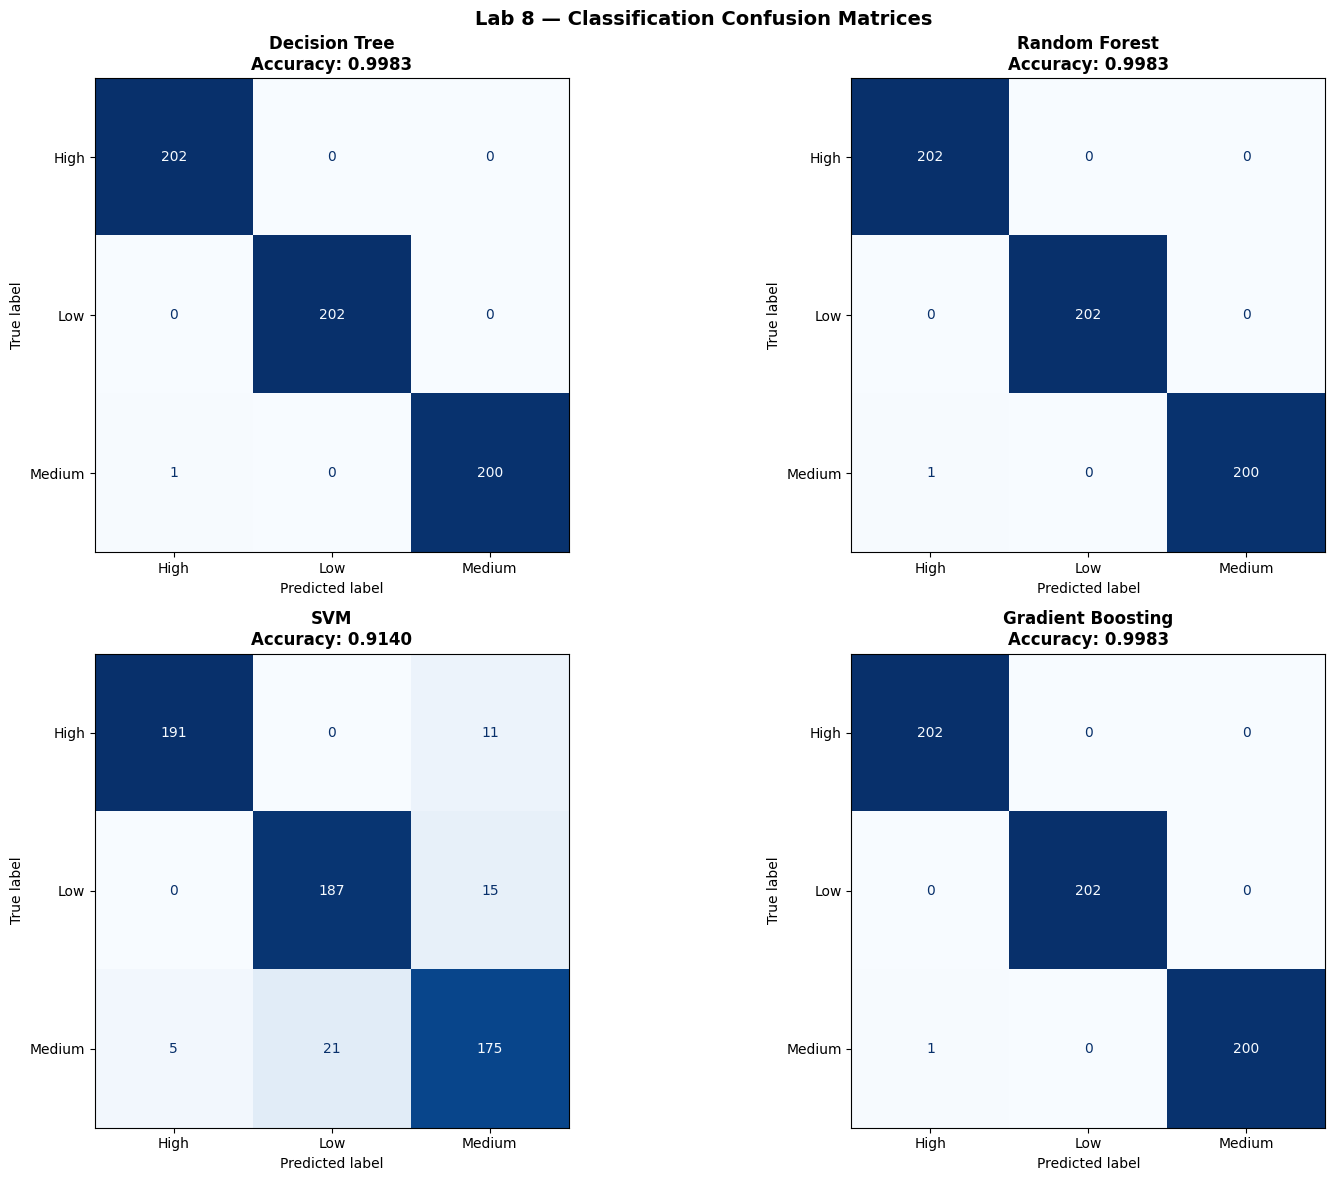

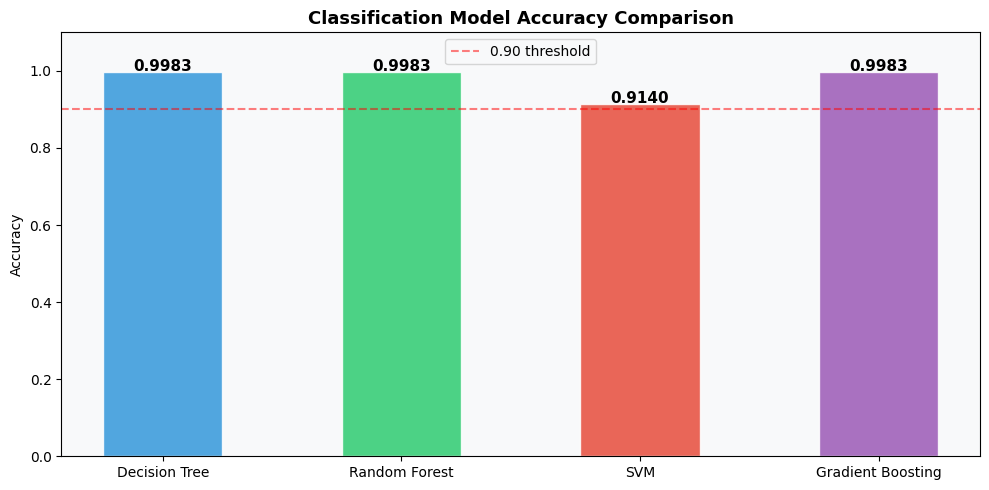

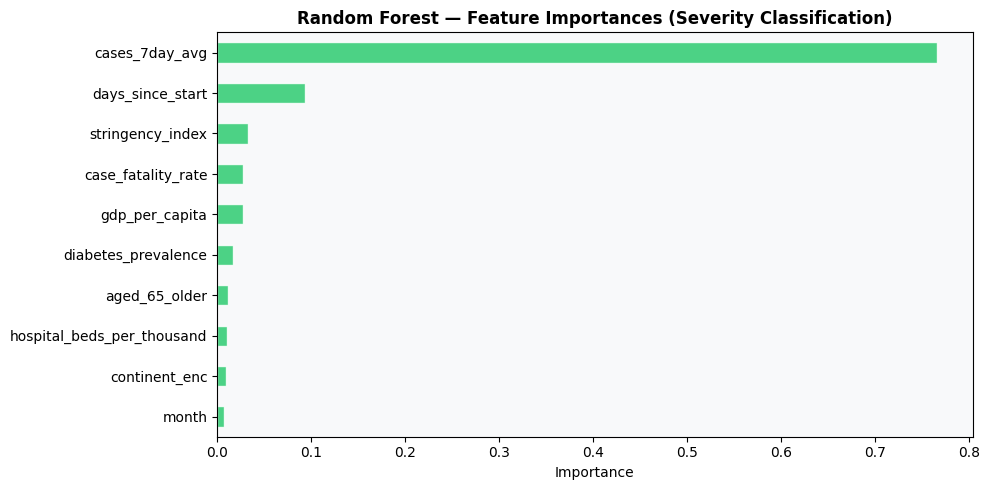

In [40]:
# ── 8.6: Classification Plots ─────────────────────── ──

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models_cls = [('Decision Tree', dt_pred), ('Random Forest', rfc_pred),
              ('SVM', svm_pred), ('Gradient Boosting', gbc_pred)]

for ax, (name, pred) in zip(axes.flatten(), models_cls):
    cm = confusion_matrix(y3_te, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=le3.classes_)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    acc = (pred == y3_te).mean()
    ax.set_title(f'{name}\nAccuracy: {acc:.4f}', fontweight='bold', fontsize=12)

plt.suptitle('Lab 8 — Classification Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Accuracy comparison bar chart
fig, ax = plt.subplots(figsize=(10, 5))
model_names = [m[0] for m in models_cls]
accuracies  = [(p==y3_te).mean() for _,p in models_cls]
bar_colors  = ['#3498db','#2ecc71','#e74c3c','#9b59b6']
bars = ax.bar(model_names, accuracies, color=bar_colors, alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.1); ax.set_ylabel('Accuracy')
ax.set_title('Classification Model Accuracy Comparison', fontweight='bold', fontsize=13)
ax.axhline(0.9, color='red', linestyle='--', alpha=0.5, label='0.90 threshold')
ax.legend(); plt.tight_layout(); plt.show()

# Feature importance (Random Forest)
fi = pd.Series(rfc.feature_importances_, index=CLS3_FEATURES).sort_values(ascending=True)
plt.figure(figsize=(10, 5))
fi.plot(kind='barh', color='#2ecc71', alpha=0.85, edgecolor='white')
plt.title('Random Forest — Feature Importances (Severity Classification)', fontweight='bold')
plt.xlabel('Importance'); plt.tight_layout(); plt.show()


In [41]:
# ── 9.1: Prepare Clustering Data ──────────────────── ──

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

CLUST_FEATURES = ['cases_per_million','deaths_per_million','cfr_pct',
                  'gdp','aged','beds','avg_stringency']
CLUST_FEATURES = [c for c in CLUST_FEATURES if c in agg.columns]

X_clust = agg[CLUST_FEATURES].fillna(agg[CLUST_FEATURES].median()).values
sc_clust = StandardScaler()
X_clust_s = sc_clust.fit_transform(X_clust)

print(f"Clustering dataset: {X_clust_s.shape}")


Clustering dataset: (15, 7)


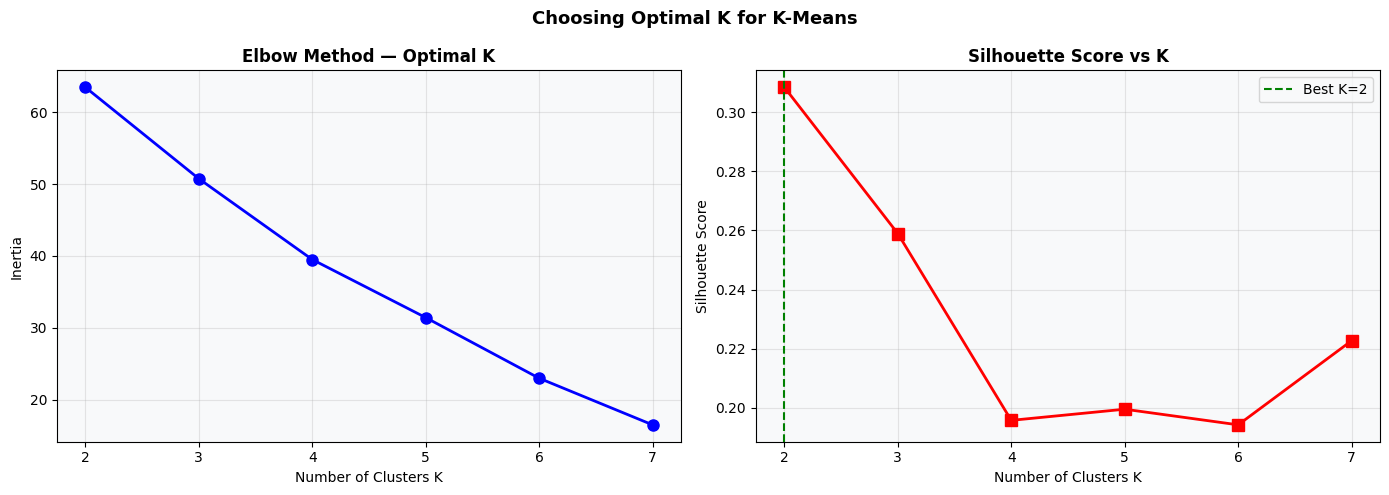

✅ Best K = 2  (Silhouette = 0.308)


In [42]:
# ── 9.2: Optimal K — Elbow + Silhouette ───────────── ──

K_range = range(2, 8)
inertias, silhouettes = [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust_s)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clust_s, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method — Optimal K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters K'); axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouettes, 'rs-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].set_xlabel('Number of Clusters K'); axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

BEST_K = K_range[np.argmax(silhouettes)]
axes[1].axvline(BEST_K, color='green', linestyle='--', label=f'Best K={BEST_K}')
axes[1].legend()

plt.suptitle('Choosing Optimal K for K-Means', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"✅ Best K = {BEST_K}  (Silhouette = {max(silhouettes):.3f})")


In [43]:
# ── 9.3: K-Means Clustering ───────────────────────── ──

kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_clust_s)
agg['km_cluster'] = km_labels

# PCA for 2D viz
pca2 = PCA(n_components=2)
X_2d = pca2.fit_transform(X_clust_s)
agg['PC1'] = X_2d[:, 0]
agg['PC2'] = X_2d[:, 1]

sil_score = silhouette_score(X_clust_s, km_labels)
db_score  = davies_bouldin_score(X_clust_s, km_labels)

print("── K-MEANS RESULTS ───────────────────────")
print(f"  K            : {BEST_K}")
print(f"  Silhouette   : {sil_score:.4f}  (higher = better, max=1)")
print(f"  Davies-Bouldin: {db_score:.4f}  (lower = better)")
print(f"\nCluster assignments:")
for i in range(BEST_K):
    countries_in = agg[agg['km_cluster']==i]['location'].tolist()
    print(f"  Cluster {i}: {countries_in}")

# Cluster profile
print("\nCluster Profiles (mean features):")
print(agg.groupby('km_cluster')[CLUST_FEATURES].mean().round(2).to_string())


── K-MEANS RESULTS ───────────────────────
  K            : 2
  Silhouette   : 0.3084  (higher = better, max=1)
  Davies-Bouldin: 1.1104  (lower = better)

Cluster assignments:
  Cluster 0: ['Australia', 'Canada', 'France', 'Germany', 'Italy', 'Japan', 'Russia', 'Spain', 'United Kingdom', 'United States']
  Cluster 1: ['Argentina', 'Brazil', 'India', 'Mexico', 'South Africa']

Cluster Profiles (mean features):
            cases_per_million  deaths_per_million  cfr_pct       gdp   aged  beds  avg_stringency
km_cluster                                                                                       
0                   347858.92             2324.77     0.78  39974.05  19.13  5.29           34.77
1                   111143.44             2169.06     2.25  13819.08   7.59  2.29           38.53


In [44]:
# ── 9.4: Hierarchical Clustering ──────────────────── ──

hc = AgglomerativeClustering(n_clusters=BEST_K, linkage='ward')
hc_labels = hc.fit_predict(X_clust_s)
agg['hc_cluster'] = hc_labels

print("\n── HIERARCHICAL CLUSTERING RESULTS ──────")
for i in range(BEST_K):
    countries_in = agg[agg['hc_cluster']==i]['location'].tolist()
    print(f"  Cluster {i}: {countries_in}")
print(f"  Silhouette: {silhouette_score(X_clust_s, hc_labels):.4f}")



── HIERARCHICAL CLUSTERING RESULTS ──────
  Cluster 0: ['Australia', 'Canada', 'France', 'Germany', 'Italy', 'Japan', 'Spain', 'United Kingdom', 'United States']
  Cluster 1: ['Argentina', 'Brazil', 'India', 'Mexico', 'Russia', 'South Africa']
  Silhouette: 0.2926


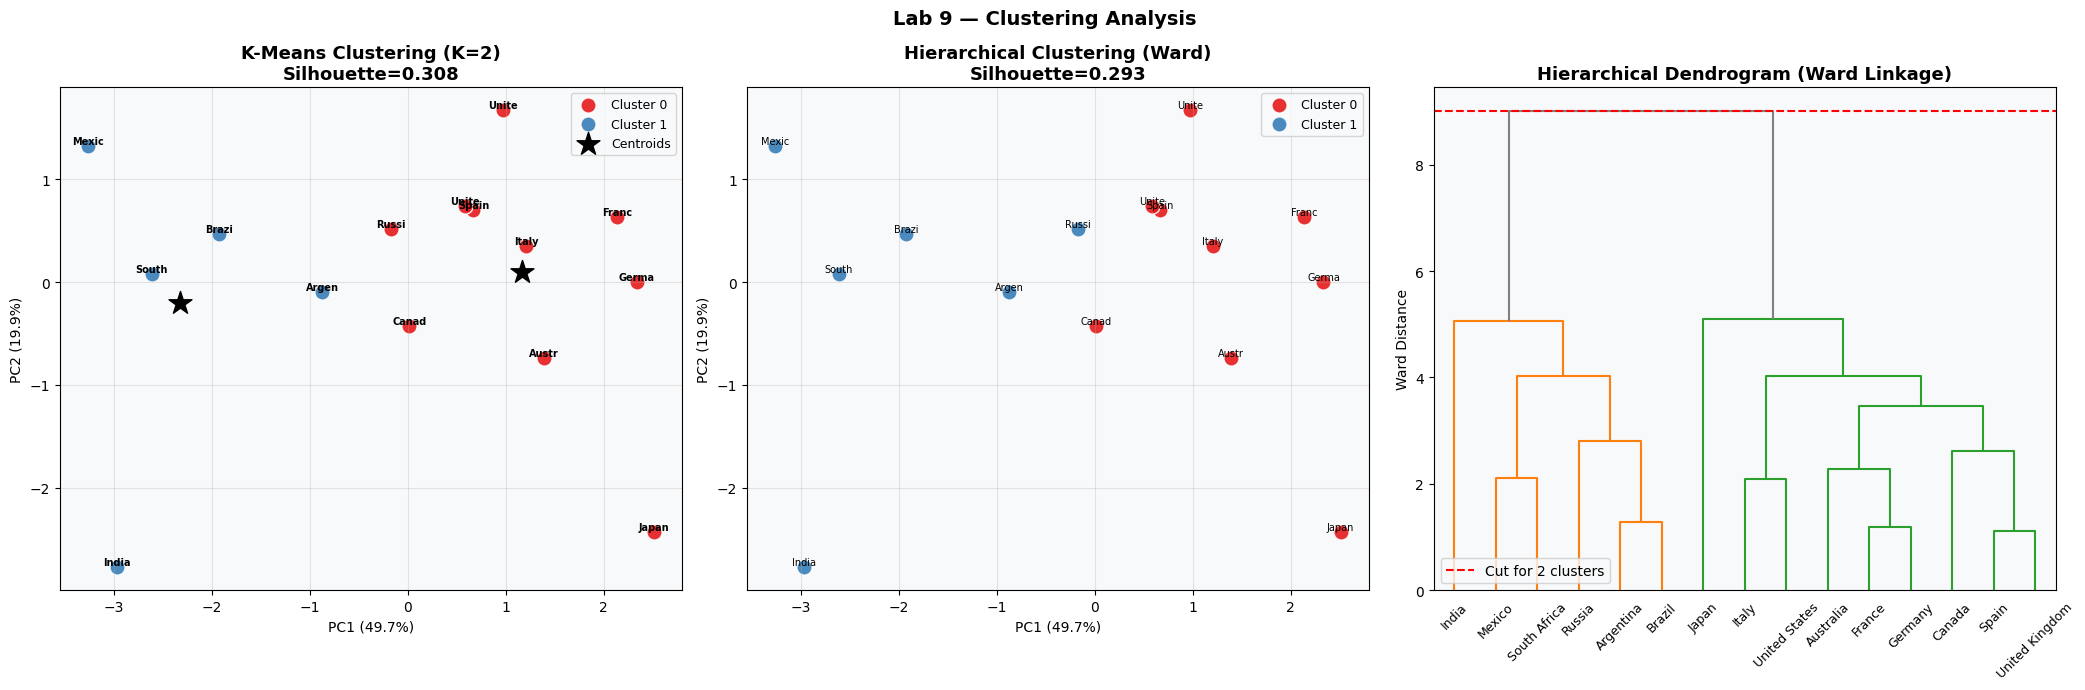

In [45]:
# ── 9.5: Clustering Visualizations ────────────────── ──

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

cluster_palette = sns.color_palette('Set1', BEST_K)

# K-Means scatter
ax = axes[0]
for k in range(BEST_K):
    mask = km_labels == k
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               color=cluster_palette[k], s=120, alpha=0.9,
               edgecolors='white', linewidths=1, label=f'Cluster {k}')
for i, row in agg.iterrows():
    ax.annotate(row['location'][:5], (row['PC1'], row['PC2']),
                fontsize=7, ha='center', va='bottom', fontweight='bold')
centers_2d = pca2.transform(kmeans.cluster_centers_)
ax.scatter(centers_2d[:,0], centers_2d[:,1], c='black', s=300, marker='*',
           zorder=10, label='Centroids')
ax.set_title(f'K-Means Clustering (K={BEST_K})\nSilhouette={sil_score:.3f}',
             fontweight='bold', fontsize=13)
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Hierarchical scatter
ax = axes[1]
for k in range(BEST_K):
    mask = hc_labels == k
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               color=cluster_palette[k], s=120, alpha=0.9,
               edgecolors='white', linewidths=1, label=f'Cluster {k}')
for i, row in agg.iterrows():
    ax.annotate(row['location'][:5], (row['PC1'], row['PC2']),
                fontsize=7, ha='center', va='bottom')
ax.set_title(f'Hierarchical Clustering (Ward)\nSilhouette={silhouette_score(X_clust_s,hc_labels):.3f}',
             fontweight='bold', fontsize=13)
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Dendrogram
ax = axes[2]
linked = linkage(X_clust_s, method='ward')
dendrogram(linked, ax=ax,
           labels=agg['location'].values,
           leaf_rotation=45, leaf_font_size=9,
           color_threshold=linked[-(BEST_K-1), 2],
           above_threshold_color='grey')
ax.axhline(y=linked[-(BEST_K-1), 2], color='red', linestyle='--', linewidth=1.5,
           label=f'Cut for {BEST_K} clusters')
ax.set_title('Hierarchical Dendrogram (Ward Linkage)', fontweight='bold', fontsize=13)
ax.set_ylabel('Ward Distance'); ax.legend()

plt.suptitle('Lab 9 — Clustering Analysis', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


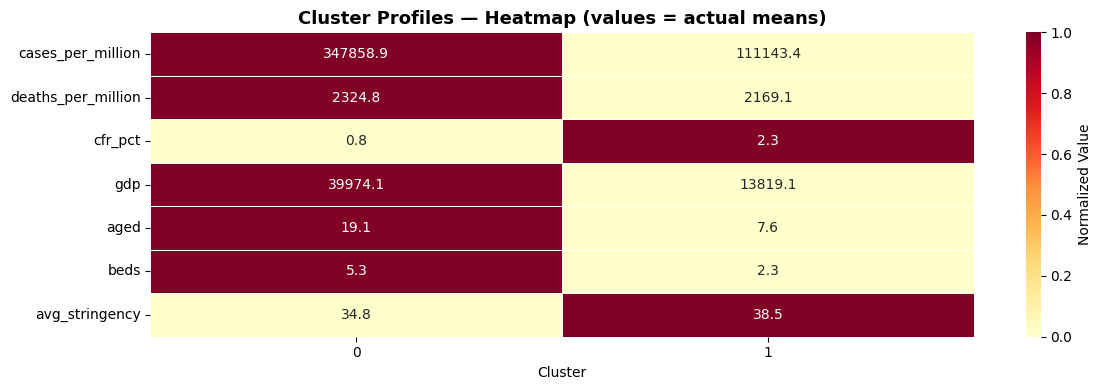

In [46]:
# ── 9.6: Cluster Heatmap (profiles) ───────────────── ──

clust_profile = agg.groupby('km_cluster')[CLUST_FEATURES].mean()
clust_profile_norm = (clust_profile - clust_profile.min()) / (clust_profile.max() - clust_profile.min())

plt.figure(figsize=(12, 4))
sns.heatmap(clust_profile_norm.T, annot=clust_profile.T, fmt='.1f',
            cmap='YlOrRd', linewidths=0.5, cbar_kws={'label':'Normalized Value'})
plt.title('Cluster Profiles — Heatmap (values = actual means)', fontweight='bold', fontsize=13)
plt.xlabel('Cluster'); plt.tight_layout(); plt.show()


In [47]:
# ── 10.1: Prepare Time-Series Data for LSTM ───────── ──

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (LSTM, Dense, Dropout, BatchNormalization,
                                      Conv1D, MaxPooling1D, Flatten,
                                      GRU, Bidirectional, Input, Attention)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

# Use GLOBAL daily aggregated data
global_ts = df.groupby('date').agg(
    new_cases     = ('new_cases','sum'),
    new_deaths    = ('new_deaths','sum'),
    avg_stringency= ('stringency_index','mean'),
    new_vacc      = ('new_vaccinations','sum')
).reset_index().sort_values('date').reset_index(drop=True)

global_ts['cases_7d'] = global_ts['new_cases'].rolling(7, min_periods=1).mean()
global_ts['deaths_7d']= global_ts['new_deaths'].rolling(7, min_periods=1).mean()
global_ts = global_ts.fillna(method='bfill')

# Normalize
from sklearn.preprocessing import MinMaxScaler
feature_cols = ['new_cases','new_deaths','avg_stringency','new_vacc','cases_7d']
sc_ts = MinMaxScaler()
data_scaled = sc_ts.fit_transform(global_ts[feature_cols].values)

# Create sequences (WINDOW → next value)
WINDOW   = 30   # 30 days lookback
HORIZON  = 1    # predict next day

def make_sequences(data, window, horizon=1):
    X, y = [], []
    for i in range(len(data) - window - horizon + 1):
        X.append(data[i : i + window])
        y.append(data[i + window, 0])    # predict new_cases (column 0)
    return np.array(X), np.array(y)

X_seq, y_seq = make_sequences(data_scaled, WINDOW, HORIZON)
split = int(len(X_seq) * 0.8)
X_tr_seq, X_te_seq = X_seq[:split], X_seq[split:]
y_tr_seq, y_te_seq = y_seq[:split], y_seq[split:]

print(f"Sequence shape : X={X_seq.shape}, y={y_seq.shape}")
print(f"Train: {X_tr_seq.shape}, Test: {X_te_seq.shape}")


TensorFlow version: 2.19.0
GPU available: True
Sequence shape : X=(1656, 30, 5), y=(1656,)
Train: (1324, 30, 5), Test: (332, 30, 5)


In [48]:
# ── 10.2: Model 1 — LSTM ───────────────────────────── ──

def build_lstm(window, n_features, units=64):
    model = Sequential([
        LSTM(units, return_sequences=True,
             input_shape=(window, n_features)),
        Dropout(0.2),
        LSTM(units // 2),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ], name='LSTM')
    model.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
    return model

lstm_model = build_lstm(WINDOW, len(feature_cols))
lstm_model.summary()

es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
lr_cb = ReduceLROnPlateau(monitor='val_loss', patience=7, factor=0.5, verbose=1)

print("\n🔄 Training LSTM...")
lstm_hist = lstm_model.fit(
    X_tr_seq, y_tr_seq,
    validation_split=0.15,
    epochs=100,
    batch_size=32,
    callbacks=[es, lr_cb],
    verbose=1
)
print("✅ LSTM training complete!")


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,425 (122.75 KB)

 Trainable params: 31,425 (122.75 KB)

 Non-trainable params: 0 (0.00 B)


🔄 Training LSTM...
Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0079 - mae: 0.0456 - val_loss: 2.3272e-04 - val_mae: 0.0151 - learning_rate: 0.0010
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0064 - mae: 0.0428 - val_loss: 4.5104e-05 - val_mae: 0.0039 - learning_rate: 0.0010
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0066 - mae: 0.0400 - val_loss: 7.8440e-05 - val_mae: 0.0081 - learning_rate: 0.0010
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0063 - mae: 0.0403 - val_loss: 4.5692e-05 - val_mae: 0.0035 - learning_rate: 0.0010
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0060 - mae: 0.0384 - val_loss: 1.4352e-04 - val_mae: 0.0117 - learning_rate: 0.0010
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0061 - mae: 0.0394 - val_loss: 4.7150e-05 - val_mae: 0.0046 - learning_rate: 0.0010
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0061 - mae: 0.0392 - val_loss: 9.3478e-05 

In [49]:
# ── 10.3: Model 2 — Bidirectional GRU ─────────────── ──

def build_bigru(window, n_features, units=64):
    model = Sequential([
        Bidirectional(GRU(units, return_sequences=True),
                      input_shape=(window, n_features)),
        Dropout(0.2),
        Bidirectional(GRU(units // 2)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ], name='BiGRU')
    model.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
    return model

bigru_model = build_bigru(WINDOW, len(feature_cols))
bigru_model.summary()

print("\n🔄 Training Bidirectional GRU...")
bigru_hist = bigru_model.fit(
    X_tr_seq, y_tr_seq,
    validation_split=0.15,
    epochs=100,
    batch_size=32,
    callbacks=[es, lr_cb],
    verbose=1
)
print("✅ BiGRU training complete!")


Model: "BiGRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 128)        │        27,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,481 (236.25 KB)

 Trainable params: 60,481 (236.25 KB)

 Non-trainable params: 0 (0.00 B)


🔄 Training Bidirectional GRU...
Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0068 - mae: 0.0413 - val_loss: 5.6973e-05 - val_mae: 0.0060 - learning_rate: 0.0010
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0064 - mae: 0.0384 - val_loss: 5.9030e-04 - val_mae: 0.0238 - learning_rate: 0.0010
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0067 - mae: 0.0459 - val_loss: 4.9379e-05 - val_mae: 0.0040 - learning_rate: 0.0010
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0057 - mae: 0.0362 - val_loss: 5.4041e-04 - val_mae: 0.0229 - learning_rate: 0.0010
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0057 - mae: 0.0406 - val_loss: 1.0582e-04 - val_mae: 0.0081 - learning_rate: 0.0010
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0058 - mae: 0.0377 - val_loss: 1.1018e-04 - val_mae: 0.0102 - learning_rate: 0.0010
Epoch 7/100
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0052 - mae: 0.0329
Epoch 7: R

In [50]:
# ── 10.4: Model 3 — CNN-LSTM Hybrid ───────────────── ──

def build_cnn_lstm(window, n_features):
    model = Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu',
               input_shape=(window, n_features)),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=32, kernel_size=3, activation='relu'),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ], name='CNN_LSTM')
    model.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
    return model

cnn_lstm = build_cnn_lstm(WINDOW, len(feature_cols))
cnn_lstm.summary()

print("\n🔄 Training CNN-LSTM Hybrid...")
cnn_hist = cnn_lstm.fit(
    X_tr_seq, y_tr_seq,
    validation_split=0.15,
    epochs=100,
    batch_size=32,
    callbacks=[es, lr_cb],
    verbose=1
)
print("✅ CNN-LSTM training complete!")


Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 28, 64)         │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 12, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,145 (133.38 KB)

 Trainable params: 34,145 (133.38 KB)

 Non-trainable params: 0 (0.00 B)


🔄 Training CNN-LSTM Hybrid...
Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0065 - mae: 0.0407 - val_loss: 6.2941e-05 - val_mae: 0.0067 - learning_rate: 0.0010
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0062 - mae: 0.0370 - val_loss: 1.1128e-04 - val_mae: 0.0101 - learning_rate: 0.0010
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0061 - mae: 0.0383 - val_loss: 1.4320e-04 - val_mae: 0.0117 - learning_rate: 0.0010
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0059 - mae: 0.0379 - val_loss: 4.0132e-05 - val_mae: 0.0029 - learning_rate: 0.0010
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0051 - mae: 0.0349 - val_loss: 2.5754e-05 - val_mae: 0.0029 - learning_rate: 0.0010
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0033 - mae: 0.0279 - val_loss: 3.5876e-05 - val_mae: 0.0049 - learning_rate: 0.0010
Epoch 7/100
31/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0014 - mae: 0.0204
Epoch 7: Reduce

In [51]:
# ── 10.5: DL Evaluation ────────────────────────────── ──

def evaluate_dl(model, X_te, y_te, sc, name):
    y_pred_n = model.predict(X_te).flatten()

    # Inverse transform (only column 0 = new_cases)
    dummy = np.zeros((len(y_te), len(feature_cols)))
    dummy[:, 0] = y_te
    y_actual = sc.inverse_transform(dummy)[:, 0]

    dummy2 = np.zeros((len(y_pred_n), len(feature_cols)))
    dummy2[:, 0] = y_pred_n
    y_predicted = sc.inverse_transform(dummy2)[:, 0]

    rmse = np.sqrt(mean_squared_error(y_actual, y_predicted))
    mae  = mean_absolute_error(y_actual, y_predicted)
    r2   = r2_score(y_actual, y_predicted)
    mape = np.mean(np.abs((y_actual - y_predicted) / (y_actual + 1))) * 100

    print(f"\n── {name} ─────────────────────────")
    print(f"  R²   : {r2:.4f}")
    print(f"  RMSE : {rmse:,.0f}")
    print(f"  MAE  : {mae:,.0f}")
    print(f"  MAPE : {mape:.2f}%")
    return y_actual, y_predicted, r2

y_act_l, y_pred_l, r2_l = evaluate_dl(lstm_model,   X_te_seq, y_te_seq, sc_ts, 'LSTM')
y_act_g, y_pred_g, r2_g = evaluate_dl(bigru_model,  X_te_seq, y_te_seq, sc_ts, 'BiGRU')
y_act_c, y_pred_c, r2_c = evaluate_dl(cnn_lstm,     X_te_seq, y_te_seq, sc_ts, 'CNN-LSTM')


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

── LSTM ─────────────────────────
  R²   : 0.1707
  RMSE : 25,201
  MAE  : 18,409
  MAPE : 1339368.59%
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step

── BiGRU ─────────────────────────
  R²   : -2.1214
  RMSE : 48,893
  MAE  : 46,845
  MAPE : 4027310.51%
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

── CNN-LSTM ─────────────────────────
  R²   : 0.7291
  RMSE : 14,402
  MAE  : 8,988
  MAPE : 570892.69%


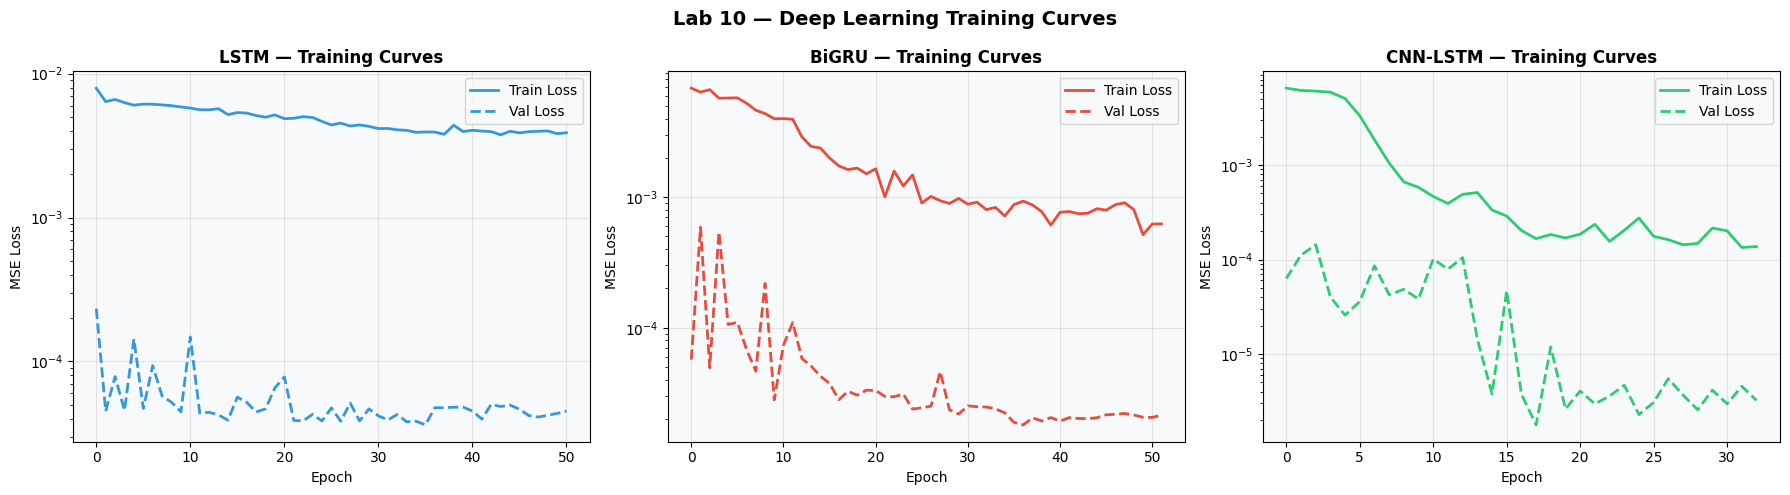

In [52]:
# ── 10.6: DL Training Curves ───────────────────────── ──

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, hist, name, color in zip(
    axes,
    [lstm_hist, bigru_hist, cnn_hist],
    ['LSTM', 'BiGRU', 'CNN-LSTM'],
    ['#3498db','#e74c3c','#2ecc71']
):
    ax.plot(hist.history['loss'],     color=color, linewidth=2, label='Train Loss')
    ax.plot(hist.history['val_loss'], color=color, linewidth=2, linestyle='--', label='Val Loss')
    ax.set_title(f'{name} — Training Curves', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

plt.suptitle('Lab 10 — Deep Learning Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


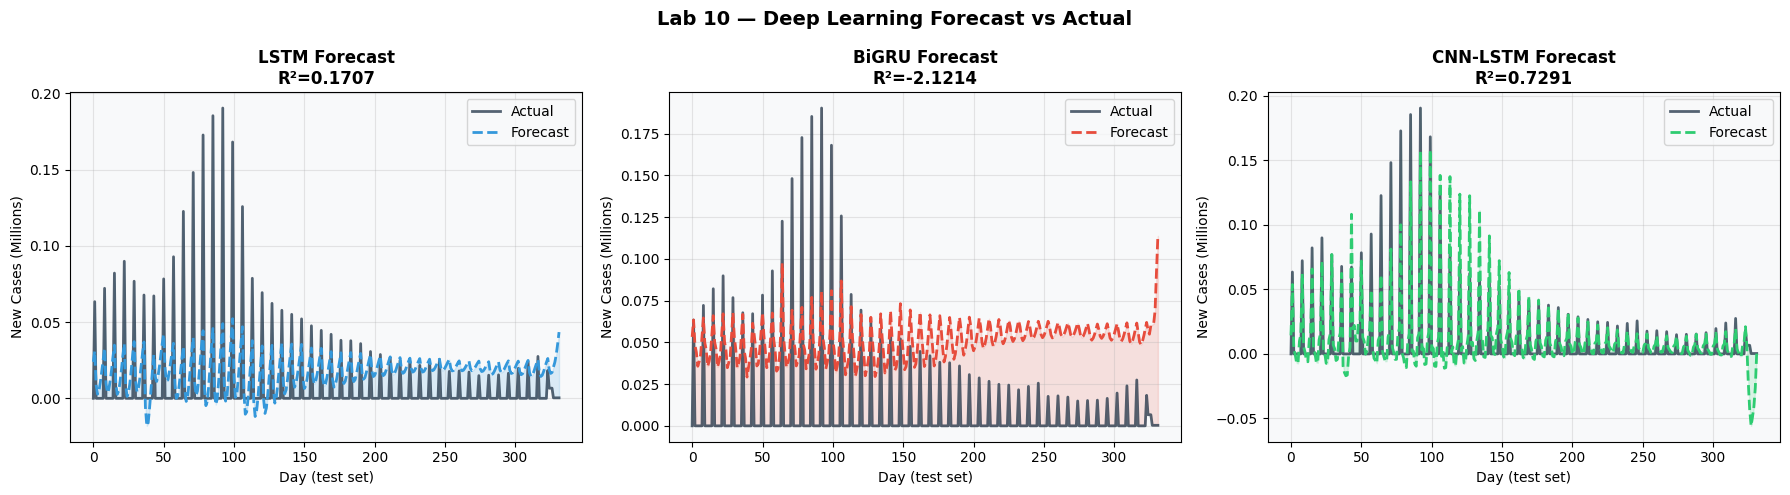

In [53]:
# ── 10.7: DL Forecast Plots ────────────────────────── ──

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pairs = [('LSTM', y_act_l, y_pred_l, r2_l, '#3498db'),
         ('BiGRU', y_act_g, y_pred_g, r2_g, '#e74c3c'),
         ('CNN-LSTM', y_act_c, y_pred_c, r2_c, '#2ecc71')]

for ax, (name, actual, predicted, r2, color) in zip(axes, pairs):
    t = range(len(actual))
    ax.plot(t, actual/1e6,    color='#2c3e50', linewidth=2, label='Actual', alpha=0.8)
    ax.plot(t, predicted/1e6, color=color,     linewidth=2, label='Forecast', linestyle='--')
    ax.fill_between(t, actual/1e6, predicted/1e6, alpha=0.15, color=color)
    ax.set_title(f'{name} Forecast\nR²={r2:.4f}', fontweight='bold')
    ax.set_xlabel('Day (test set)'); ax.set_ylabel('New Cases (Millions)')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Lab 10 — Deep Learning Forecast vs Actual', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


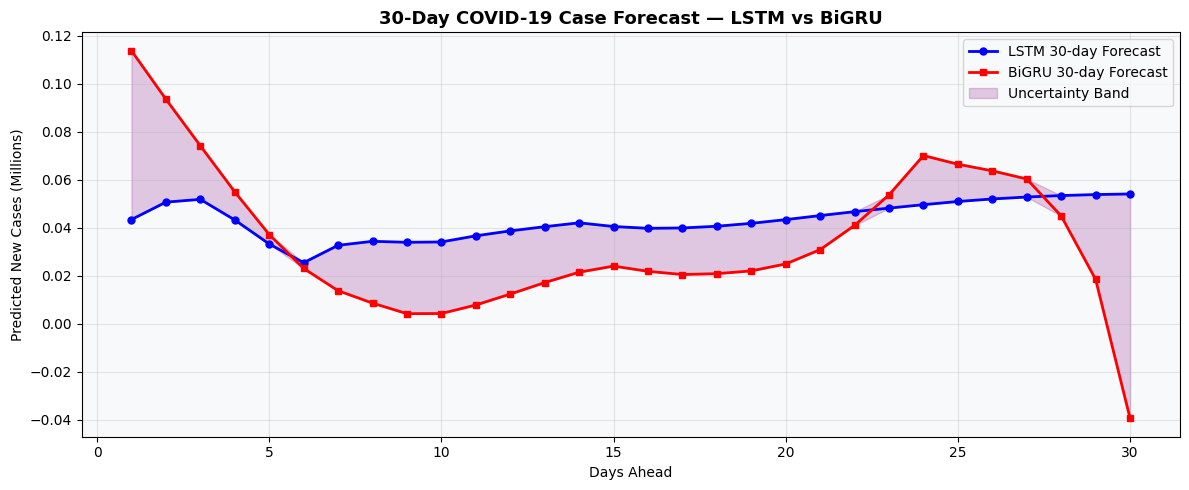

✅ 30-day forecast complete!

        COVID-19 DATA SCIENCE — COMPLETE RESULTS SUMMARY

📊 DATASET
   Source     : Our World in Data (owid-covid-data.csv)
   Countries  : 15
   Records    : 25,129
   Date range : 2020-01-01 → 2024-08-12

📈 REGRESSION (predict log(new_cases))
   Linear Regression   R² = 0.0105
   Ridge Regression    R² = 0.0105

🏷️  CLASSIFICATION (severity: Low/Medium/High)
   Decision Tree       Acc = 0.9983
   Random Forest       Acc = 0.9983
   SVM (RBF)           Acc = 0.9140
   Gradient Boosting   Acc = 0.9983

🔵 CLUSTERING
   K-Means  (K=2)  Silhouette = 0.3084
   Hierarch (K=2)  Silhouette = 0.2926

🧠 DEEP LEARNING (time-series forecasting)
   LSTM               R² = 0.1707
   BiGRU              R² = -2.1214
   CNN-LSTM           R² = 0.7291

✅ All 10 Labs completed successfully!


In [54]:
# ── 10.8: Future Forecast (30 days) ───────────────── ──

def forecast_future(model, last_sequence, sc, n_days=30):
    """Recursively forecast n_days ahead."""
    seq = last_sequence.copy()
    forecasts = []
    for _ in range(n_days):
        pred = model.predict(seq[np.newaxis, :, :], verbose=0)[0, 0]
        forecasts.append(pred)
        new_row = np.zeros(len(feature_cols))
        new_row[0] = pred
        seq = np.vstack([seq[1:], new_row])

    dummy = np.zeros((n_days, len(feature_cols)))
    dummy[:, 0] = forecasts
    return sc.inverse_transform(dummy)[:, 0]

last_seq = X_te_seq[-1]
future_lstm  = forecast_future(lstm_model,  last_seq, sc_ts, 30)
future_bigru = forecast_future(bigru_model, last_seq, sc_ts, 30)

plt.figure(figsize=(12, 5))
days = range(1, 31)
plt.plot(days, future_lstm/1e6,  'b-o', linewidth=2, markersize=5, label='LSTM 30-day Forecast')
plt.plot(days, future_bigru/1e6, 'r-s', linewidth=2, markersize=5, label='BiGRU 30-day Forecast')
plt.fill_between(days,
                 np.minimum(future_lstm, future_bigru)/1e6,
                 np.maximum(future_lstm, future_bigru)/1e6,
                 alpha=0.2, color='purple', label='Uncertainty Band')
plt.xlabel('Days Ahead'); plt.ylabel('Predicted New Cases (Millions)')
plt.title('30-Day COVID-19 Case Forecast — LSTM vs BiGRU', fontweight='bold', fontsize=13)
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print("✅ 30-day forecast complete!")



print("\n" + "="*65)
print("        COVID-19 DATA SCIENCE — COMPLETE RESULTS SUMMARY")
print("="*65)

print("\n📊 DATASET")
print(f"   Source     : Our World in Data (owid-covid-data.csv)")
print(f"   Countries  : {df['location'].nunique()}")
print(f"   Records    : {len(df):,}")
print(f"   Date range : {df['date'].min().date()} → {df['date'].max().date()}")

print("\n📈 REGRESSION (predict log(new_cases))")
print(f"   Linear Regression   R² = {r2_score(y_test, y_pred_lr):.4f}")
print(f"   Ridge Regression    R² = {r2_score(y_test, y_pred_ridge):.4f}")

print("\n🏷️  CLASSIFICATION (severity: Low/Medium/High)")
print(f"   Decision Tree       Acc = {(dt_pred==y3_te).mean():.4f}")
print(f"   Random Forest       Acc = {(rfc_pred==y3_te).mean():.4f}")
print(f"   SVM (RBF)           Acc = {(svm_pred==y3_te).mean():.4f}")
print(f"   Gradient Boosting   Acc = {(gbc_pred==y3_te).mean():.4f}")

print("\n🔵 CLUSTERING")
print(f"   K-Means  (K={BEST_K})  Silhouette = {silhouette_score(X_clust_s,km_labels):.4f}")
print(f"   Hierarch (K={BEST_K})  Silhouette = {silhouette_score(X_clust_s,hc_labels):.4f}")

print("\n🧠 DEEP LEARNING (time-series forecasting)")
print(f"   LSTM               R² = {r2_l:.4f}")
print(f"   BiGRU              R² = {r2_g:.4f}")
print(f"   CNN-LSTM           R² = {r2_c:.4f}")

print("\n" + "="*65)
print("✅ All 10 Labs completed successfully!")
print("="*65)
